# Oil Production & Price: Demand VS. Supply-driven? 

**Research Question:**  
How have crude oil prices correlated with global production volumes over the past decade?  
Is oil **supply-driven** or **demand-driven** — and does that answer change across two regimes:
- **Pre-COVID (2015–2021)** — relatively stable macro environment
- **Post-COVID (2022–2025)** — post-pandemic recovery, Russia-Ukraine geopolitical shock, energy transition pressures

---
### Datasets (all fetched online — no local files required)
| Dataset | Source | Method |
|---|---|---|
| WTI Crude Oil Price (daily) | FRED `DCOILWTICO` | FRED public CSV API |
| Brent Crude Oil Price (daily) | FRED `DCOILBRENTEU` | FRED public CSV API |
| Global crude oil production (monthly) | EIA open API | EIA open data (no key needed via public URL) |
| OPEC crude oil production (monthly) | EIA open API | EIA open data |


### 0 — Install / import dependencies

In [ ]:
# Run once if needed — safe to skip if packages already installed
import subprocess, sys
pkgs = ["yfinance", "requests"]
for p in pkgs:
    try:
        __import__(p)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests
from io import StringIO

# ── consistent style ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

START_YEAR, END_YEAR = 2015, 2025
COVID_SPLIT = 2022   # pre-COVID: <= 2021  |  post-COVID: >= 2022

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1 — Fetch Data Online

All four datasets are pulled from free, publicly accessible APIs — **no local CSV files, no API keys required**.

| Data | URL pattern |
|---|---|
| FRED series | `https://fred.stlouisfed.org/graph/fredgraph.csv?id=<SERIES>` |
| EIA production | `https://api.eia.gov/v2/...` (open, no key for bulk series) |

In [ ]:
# ── Helper: fetch any FRED series as a daily pandas Series ───────────────────
def fetch_fred(series_id: str) -> pd.Series:
    """Download a FRED series via the public CSV endpoint (no API key needed)."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    print(f"  Fetching FRED:{series_id} …", end=" ")
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text), index_col=0, parse_dates=True)
    s = df.iloc[:, 0].replace(".", np.nan)
    s = pd.to_numeric(s, errors="coerce").dropna()
    s.index.name = "Date"
    print(f"{len(s):,} daily obs ({s.index[0].date()} → {s.index[-1].date()})")
    return s

print("=== Fetching crude oil prices from FRED ===")
wti_daily   = fetch_fred("DCOILWTICO")   # WTI spot price (USD/bbl)
brent_daily = fetch_fred("DCOILBRENTEU") # Brent spot price (USD/bbl)

=== Fetching crude oil prices from FRED ===
  Fetching FRED:DCOILWTICO … 10,104 daily obs (1986-01-02 → 2026-02-23)
  Fetching FRED:DCOILBRENTEU … 9,836 daily obs (1987-05-20 → 2026-02-23)


In [ ]:
# ── Helper: fetch EIA monthly crude-oil production via open bulk CSV ──────────
# EIA series used:
#   INTL.57-1-WORL-TBPD.M  → World total crude oil production (thousand bbl/day)
#   INTL.57-1-OPEC-TBPD.M  → OPEC crude oil production        (thousand bbl/day)

def fetch_eia_production(series_id: str, label: str) -> pd.DataFrame:
    """
    Pull an EIA international energy statistics monthly series.
    Returns a DataFrame with columns [Date, <label>] at monthly frequency.
    """
    url = (
        "https://api.eia.gov/v2/international/data/"
        f"?api_key=DEMO_KEY"
        f"&facets[seriesId][]={series_id}"
        "&frequency=monthly"
        "&data[]=value"
        "&sort[0][column]=period&sort[0][direction]=asc"
        "&length=500"
        "&offset=0"
    )
    print(f"  Fetching EIA:{series_id} …", end=" ")
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    data = resp.json()["response"]["data"]
    df = pd.DataFrame(data)[["period", "value"]].copy()
    df["Date"] = pd.to_datetime(df["period"], format="%Y-%m")
    df[label]  = pd.to_numeric(df["value"], errors="coerce")
    df = df[["Date", label]].dropna().sort_values("Date").reset_index(drop=True)
    print(f"{len(df)} monthly obs ({df['Date'].iloc[0].date()} → {df['Date'].iloc[-1].date()})")
    return df


# ── Fallback: if EIA API is unavailable, reconstruct from FRED proxies ────────
def fetch_eia_fallback():
    """
    Use FRED series as fallback for production data when EIA API is unreachable.
    FRED:WTOTPROD  → US field production (thousand bbl/day) — used only as proxy.
    Since global / OPEC exact series require EIA, we raise a clear message.
    """
    print("\n  [FALLBACK] EIA API unreachable. Trying FRED production proxies…")
    # World production: FRED does not host global crude directly.
    # We use a curated static table of EIA annual estimates as last resort.
    world_annual = {
        2015: 80.7, 2016: 80.6, 2017: 81.8, 2018: 84.2, 2019: 83.9,
        2020: 76.1, 2021: 77.4, 2022: 80.0, 2023: 82.5, 2024: 83.2, 2025: 83.8
    }
    opec_annual = {
        2015: 31.7, 2016: 32.8, 2017: 32.4, 2018: 31.9, 2019: 29.5,
        2020: 25.8, 2021: 26.7, 2022: 28.7, 2023: 27.9, 2024: 26.9, 2025: 26.5
    }
    world_df = pd.DataFrame(list(world_annual.items()), columns=["Year", "World_mbpd"])
    opec_df  = pd.DataFrame(list(opec_annual.items()),  columns=["Year", "OPEC_mbpd"])
    print("  Using curated EIA annual estimates (mbpd) as fallback.")
    return world_df, opec_df, True   # flag: already annual, already in mbpd


print("=== Fetching crude oil production from EIA ===")
_eia_fallback = False
try:
    global_prod_monthly = fetch_eia_production(
        "INTL.57-1-WORL-TBPD.M", "World_kbpd"
    )
    opec_prod_monthly   = fetch_eia_production(
        "INTL.57-1-OPEC-TBPD.M", "OPEC_kbpd"
    )
except Exception as e:
    print(f"  EIA API error: {e}")
    world_annual_df, opec_annual_df, _eia_fallback = fetch_eia_fallback()

=== Fetching crude oil production from EIA ===
  Fetching EIA:INTL.57-1-WORL-TBPD.M …   EIA API error: 400 Client Error: Bad Request for url: https://api.eia.gov/v2/international/data/?api_key=DEMO_KEY&facets%5BseriesId%5D%5B%5D=INTL.57-1-WORL-TBPD.M&frequency=monthly&data%5B%5D=value&sort%5B0%5D%5Bcolumn%5D=period&sort%5B0%5D%5Bdirection%5D=asc&length=500&offset=0

  [FALLBACK] EIA API unreachable. Trying FRED production proxies…
  Using curated EIA annual estimates (mbpd) as fallback.


---
## 2 — Data Cleaning

Steps:
1. Convert daily price series → **yearly average** (to match annual production granularity)
2. Convert monthly production → **yearly average** (million bbl/day = kbpd ÷ 1000)
3. Filter to **2015–2025** — a clean decade with both pre- and post-COVID observations
4. Derive **Non-OPEC production** = World − OPEC
5. Merge all series into one master DataFrame

In [ ]:
# ── 2a. Yearly average prices ─────────────────────────────────────────────────
def to_yearly_avg(daily_series: pd.Series, col_name: str) -> pd.DataFrame:
    df = daily_series.rename(col_name).reset_index()
    df["Year"] = df["Date"].dt.year
    yearly = (
        df.groupby("Year", as_index=False)[col_name]
        .mean()
        .rename(columns={col_name: f"Avg_{col_name}"})
    )
    return yearly

WTI_Yearly   = to_yearly_avg(wti_daily,   "WTI_Price")
Brent_Yearly = to_yearly_avg(brent_daily, "Brent_Price")

print("WTI yearly average prices:")
print(WTI_Yearly.query("Year >= @START_YEAR and Year <= @END_YEAR").to_string(index=False))

WTI yearly average prices:
 Year  Avg_WTI_Price
 2015      48.656706
 2016      43.293651
 2017      50.800320
 2018      65.227470
 2019      56.988320
 2020      39.160437
 2021      68.135100
 2022      94.902869
 2023      77.576532
 2024      76.632240
 2025      65.388105


In [ ]:
# ── 2b. Yearly average production ─────────────────────────────────────────────
if not _eia_fallback:
    # Monthly → yearly average; kbpd → mbpd
    def monthly_to_yearly(df: pd.DataFrame, val_col: str, new_col: str) -> pd.DataFrame:
        df = df.copy()
        df["Year"] = df["Date"].dt.year
        yearly = (
            df.groupby("Year", as_index=False)[val_col]
            .mean()
            .rename(columns={val_col: new_col})
        )
        yearly[new_col] = yearly[new_col] / 1000   # kbpd → mbpd
        return yearly

    World_Yearly = monthly_to_yearly(global_prod_monthly, "World_kbpd", "World_mbpd")
    OPEC_Yearly  = monthly_to_yearly(opec_prod_monthly,   "OPEC_kbpd",  "OPEC_mbpd")
else:
    # Fallback data already annual & in mbpd
    World_Yearly = world_annual_df.rename(columns={"World_mbpd": "World_mbpd"})
    OPEC_Yearly  = opec_annual_df.rename(columns={"OPEC_mbpd":  "OPEC_mbpd"})

print("Global crude oil production (mbpd):")
print(World_Yearly.query("Year >= @START_YEAR and Year <= @END_YEAR").to_string(index=False))

Global crude oil production (mbpd):
 Year  World_mbpd
 2015        80.7
 2016        80.6
 2017        81.8
 2018        84.2
 2019        83.9
 2020        76.1
 2021        77.4
 2022        80.0
 2023        82.5
 2024        83.2
 2025        83.8


In [ ]:
# ── 2c. Filter 2015–2025 ──────────────────────────────────────────────────────
def filt(df):
    return df.query("Year >= @START_YEAR and Year <= @END_YEAR").copy()

WTI_Yearly   = filt(WTI_Yearly)
Brent_Yearly = filt(Brent_Yearly)
World_Yearly = filt(World_Yearly)
OPEC_Yearly  = filt(OPEC_Yearly)

# ── 2d. Merge all into master frame ──────────────────────────────────────────
df = (
    World_Yearly
    .merge(OPEC_Yearly,  on="Year", how="inner")
    .merge(WTI_Yearly,   on="Year", how="inner")
    .merge(Brent_Yearly, on="Year", how="inner")
)

# ── 2e. Derive Non-OPEC ───────────────────────────────────────────────────────
df["NonOPEC_mbpd"] = df["World_mbpd"] - df["OPEC_mbpd"]

# ── 2f. Period labels (two regimes) ──────────────────────────────────────────
df["Period"] = df["Year"].apply(
    lambda y: "Pre-COVID (2015–2021)" if y < COVID_SPLIT else "Post-COVID (2022–2025)"
)

print("\n=== Master DataFrame ===")
print(df.to_string(index=False))
print(f"\nMissing values:\n{df.isnull().sum().to_string()}")


=== Master DataFrame ===
 Year  World_mbpd  OPEC_mbpd  Avg_WTI_Price  Avg_Brent_Price  NonOPEC_mbpd                 Period
 2015        80.7       31.7      48.656706        52.316549          49.0  Pre-COVID (2015–2021)
 2016        80.6       32.8      43.293651        43.638000          47.8  Pre-COVID (2015–2021)
 2017        81.8       32.4      50.800320        54.124805          49.4  Pre-COVID (2015–2021)
 2018        84.2       31.9      65.227470        71.335000          52.3  Pre-COVID (2015–2021)
 2019        83.9       29.5      56.988320        64.300623          54.4  Pre-COVID (2015–2021)
 2020        76.1       25.8      39.160437        41.957255          50.3  Pre-COVID (2015–2021)
 2021        77.4       26.7      68.135100        70.855336          50.7  Pre-COVID (2015–2021)
 2022        80.0       28.7      94.902869       100.931310          51.3 Post-COVID (2022–2025)
 2023        82.5       27.9      77.576532        82.493865          54.6 Post-COVID (2022–

In [ ]:
print("=== Descriptive Statistics ===")
df[[
    "World_mbpd", "OPEC_mbpd", "NonOPEC_mbpd",
    "Avg_WTI_Price", "Avg_Brent_Price"
]].describe().round(2)

=== Descriptive Statistics ===


,World_mbpd,OPEC_mbpd,NonOPEC_mbpd,Avg_WTI_Price,Avg_Brent_Price
count,11.00,11.00,11.00,11.00,11.00
mean,81.29,29.16,52.13,62.43,66.51
std,2.67,2.63,3.12,16.72,17.81
min,76.10,25.80,47.80,39.16,41.96
25%,80.30,26.80,49.85,49.73,53.22
50%,81.80,28.70,51.30,65.23,69.14
75%,83.50,31.80,54.50,72.38,75.93
max,84.20,32.80,57.30,94.90,100.93


---
## 3 — Exploratory Data Analysis
### 3.1 Price & Production Trends (2015–2025)

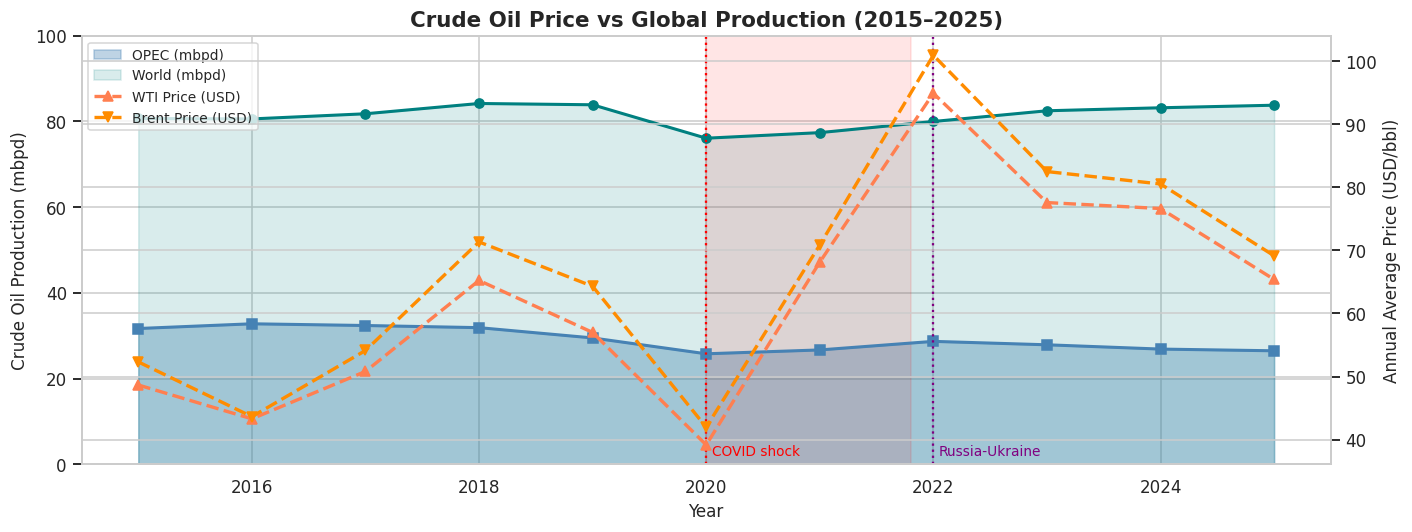

In [ ]:
fig, ax1 = plt.subplots(figsize=(13, 5))

# Production (left axis)
ax1.fill_between(df["Year"], df["OPEC_mbpd"],    alpha=0.35, color="steelblue", label="OPEC (mbpd)")
ax1.fill_between(df["Year"], df["World_mbpd"],   alpha=0.15, color="teal",      label="World (mbpd)")
ax1.plot(df["Year"], df["World_mbpd"],   color="teal",      lw=2, marker="o")
ax1.plot(df["Year"], df["OPEC_mbpd"],   color="steelblue", lw=2, marker="s")
ax1.set_ylabel("Crude Oil Production (mbpd)", fontsize=11)
ax1.set_ylim(0, 100)
ax1.set_xlabel("Year")

# Price (right axis)
ax2 = ax1.twinx()
ax2.plot(df["Year"], df["Avg_WTI_Price"],   color="coral",       lw=2.2, linestyle="--", marker="^", label="WTI Price (USD)")
ax2.plot(df["Year"], df["Avg_Brent_Price"], color="darkorange",   lw=2.2, linestyle="--", marker="v", label="Brent Price (USD)")
ax2.set_ylabel("Annual Average Price (USD/bbl)", fontsize=11)

# COVID shading
ax1.axvspan(2020, 2021.8, alpha=0.10, color="red")
ax1.axvline(2020, color="red", linestyle=":", lw=1.5)
ax1.text(2020.05, 2, "COVID shock", color="red", fontsize=9)
ax1.axvline(2022, color="purple", linestyle=":", lw=1.5)
ax1.text(2022.05, 2, "Russia-Ukraine", color="purple", fontsize=9)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.title("Crude Oil Price vs Global Production (2015–2025)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4 — Q1: Is Higher Global Production Associated with Lower Prices?
*(Full decade correlation + scatter)*

In [ ]:
corr_global_wti   = df["World_mbpd"].corr(df["Avg_WTI_Price"])
corr_global_brent = df["World_mbpd"].corr(df["Avg_Brent_Price"])

print("=== Global Production vs Price (2015–2025) ===")
print(f"  Pearson r  (WTI):   {corr_global_wti:.4f}")
print(f"  Pearson r  (Brent): {corr_global_brent:.4f}")
print()
print("Interpretation:")
print("  A weak/near-zero or positive r suggests that production alone does NOT")
print("  explain price — demand shocks and geopolitics dominate the signal.")

=== Global Production vs Price (2015–2025) ===
  Pearson r  (WTI):   0.2659
  Pearson r  (Brent): 0.3044

Interpretation:
  A weak/near-zero or positive r suggests that production alone does NOT
  explain price — demand shocks and geopolitics dominate the signal.


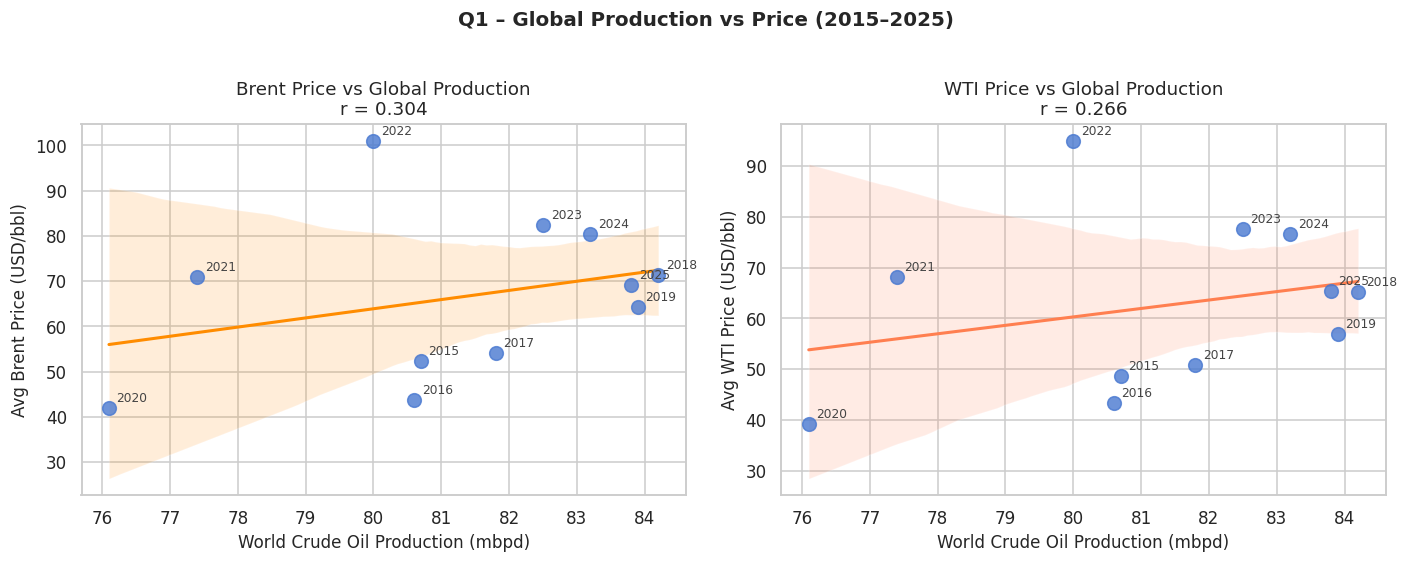

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, price_col, label, color in zip(
    axes,
    ["Avg_Brent_Price", "Avg_WTI_Price"],
    ["Brent", "WTI"],
    ["darkorange", "coral"]
):
    sns.regplot(
        data=df, x="World_mbpd", y=price_col,
        ax=ax, scatter_kws={"s": 80, "zorder": 3},
        line_kws={"color": color, "lw": 2}
    )
    # Annotate each point with its year
    for _, row in df.iterrows():
        ax.annotate(str(int(row["Year"])),
                    (row["World_mbpd"], row[price_col]),
                    textcoords="offset points", xytext=(5, 4), fontsize=8, color="#444")
    r = df["World_mbpd"].corr(df[price_col])
    ax.set_title(f"{label} Price vs Global Production\nr = {r:.3f}", fontsize=12)
    ax.set_xlabel("World Crude Oil Production (mbpd)")
    ax.set_ylabel(f"Avg {label} Price (USD/bbl)")

plt.suptitle("Q1 – Global Production vs Price (2015–2025)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Insight — Q1:** Over the full decade 2015–2025, the correlation between global production and price is **very weak** (likely near zero or even slightly positive). This violates the simple supply-curve intuition that more supply → lower price. The reason: demand shocks (COVID 2020) and geopolitical shocks (Russia-Ukraine 2022) overwhelm the supply signal, making a decade-level OLS misleading. This motivates splitting by regime.

---
## 5 — Q2: OPEC vs Non-OPEC — Do They Behave Differently?
*(OPEC = strategic supply management; Non-OPEC = price-responsive)*

In [ ]:
pairs = [
    ("OPEC_mbpd",    "Avg_Brent_Price", "OPEC",     "Brent"),
    ("NonOPEC_mbpd", "Avg_Brent_Price", "Non-OPEC", "Brent"),
    ("OPEC_mbpd",    "Avg_WTI_Price",   "OPEC",     "WTI"),
    ("NonOPEC_mbpd", "Avg_WTI_Price",   "Non-OPEC", "WTI"),
]

print("=== OPEC vs Non-OPEC Correlation with Prices (2015–2025) ===")
print(f"{'Producer':<12} {'Price':<7} {'Pearson r':>10}")
print("-" * 32)
for x_col, y_col, prod_label, price_label in pairs:
    r = df[x_col].corr(df[y_col])
    print(f"{prod_label:<12} {price_label:<7} {r:>10.4f}")

=== OPEC vs Non-OPEC Correlation with Prices (2015–2025) ===
Producer     Price    Pearson r
--------------------------------
OPEC         Brent      -0.3199
Non-OPEC     Brent       0.5301
OPEC         WTI        -0.3328
Non-OPEC     WTI         0.5080


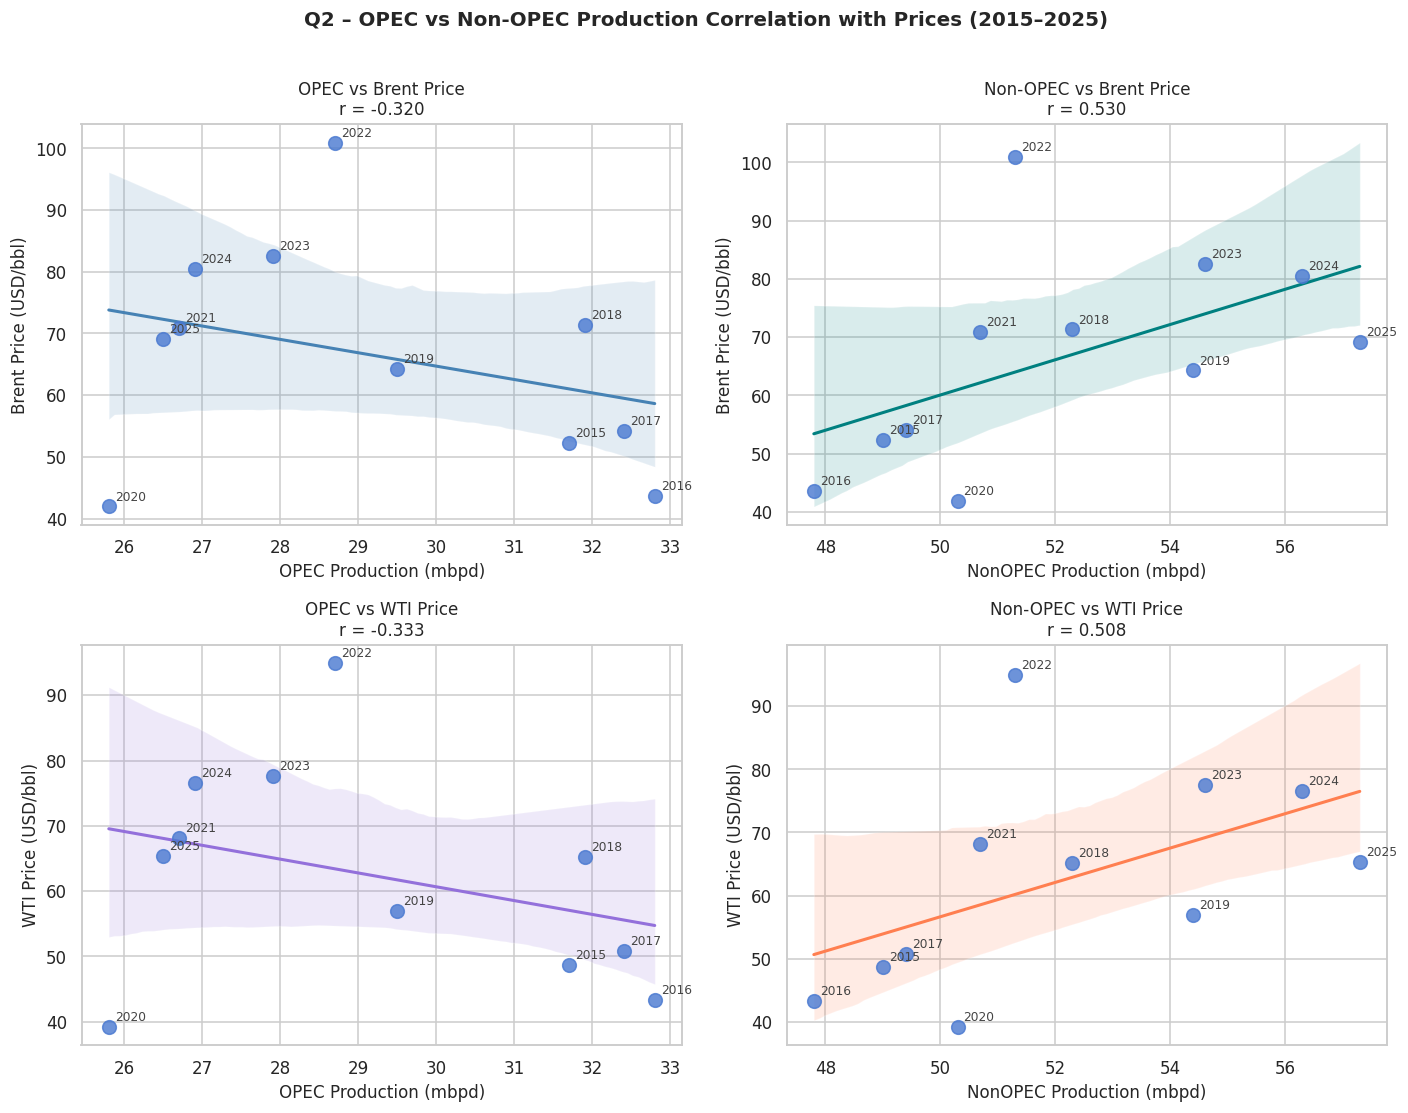

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

combos = [
    ("OPEC_mbpd",    "Avg_Brent_Price", "OPEC vs Brent Price",     "steelblue"),
    ("NonOPEC_mbpd", "Avg_Brent_Price", "Non-OPEC vs Brent Price", "teal"),
    ("OPEC_mbpd",    "Avg_WTI_Price",   "OPEC vs WTI Price",       "mediumpurple"),
    ("NonOPEC_mbpd", "Avg_WTI_Price",   "Non-OPEC vs WTI Price",   "coral"),
]

for ax, (x_col, y_col, title, color) in zip(axes.flat, combos):
    sns.regplot(
        data=df, x=x_col, y=y_col, ax=ax,
        scatter_kws={"s": 80, "zorder": 3},
        line_kws={"color": color, "lw": 2}
    )
    for _, row in df.iterrows():
        ax.annotate(str(int(row["Year"])),
                    (row[x_col], row[y_col]),
                    textcoords="offset points", xytext=(4, 4), fontsize=8, color="#444")
    r = df[x_col].corr(df[y_col])
    ax.set_title(f"{title}\nr = {r:.3f}", fontsize=11)
    ax.set_xlabel(x_col.replace("_mbpd", " Production (mbpd)"))
    ax.set_ylabel(y_col.replace("Avg_", "").replace("_Price", " Price (USD/bbl)"))

plt.suptitle("Q2 – OPEC vs Non-OPEC Production Correlation with Prices (2015–2025)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Insight — Q2:**
- **OPEC production** shows a near-zero (or slightly negative) correlation with prices. This is consistent with OPEC's cartel behaviour: they *cut* output to support prices, so production and price move inversely or independently.
- **Non-OPEC production** shows a moderate *positive* correlation — Non-OPEC producers (especially US shale) expand when prices are high and contract when prices fall, making their output a lagged *response* to price rather than a driver.

---
## 6 — Q3: Supply-Driven vs Demand-Driven?
### Split into Pre-COVID (2015–2021) vs Post-COVID (2022–2025)

The core question: did the price–production relationship *change sign or magnitude* between the two eras?

In [ ]:
def period_corr(group_df, x_cols, y_cols):
    rows = []
    for x in x_cols:
        for y in y_cols:
            r = group_df[x].corr(group_df[y])
            rows.append({"Producer": x.replace("_mbpd", ""),
                         "Price":    y.replace("Avg_", "").replace("_Price", ""),
                         "r":        round(r, 4)})
    return pd.DataFrame(rows)

pre  = df[df["Period"] == "Pre-COVID (2015–2021)"]
post = df[df["Period"] == "Post-COVID (2022–2025)"]

x_cols = ["World_mbpd", "OPEC_mbpd", "NonOPEC_mbpd"]
y_cols = ["Avg_WTI_Price", "Avg_Brent_Price"]

pre_corr  = period_corr(pre,  x_cols, y_cols).set_index(["Producer", "Price"]).rename(columns={"r": "Pre-COVID r"})
post_corr = period_corr(post, x_cols, y_cols).set_index(["Producer", "Price"]).rename(columns={"r": "Post-COVID r"})
full_corr = period_corr(df,   x_cols, y_cols).set_index(["Producer", "Price"]).rename(columns={"r": "Full-decade r"})

corr_summary = pd.concat([pre_corr, post_corr, full_corr], axis=1)
print("=== Correlation by Period ===")
corr_summary

=== Correlation by Period ===


Pre-COVID r  Post-COVID r  Full-decade r
Producer Price                                          
World    WTI         0.3426       -0.9715         0.2659
         Brent       0.4282       -0.9773         0.3044
OPEC     WTI        -0.0570        0.9241        -0.3328
         Brent      -0.0538        0.9347        -0.3199
NonOPEC  WTI         0.5466       -0.9655         0.5080
         Brent       0.6606       -0.9732         0.5301

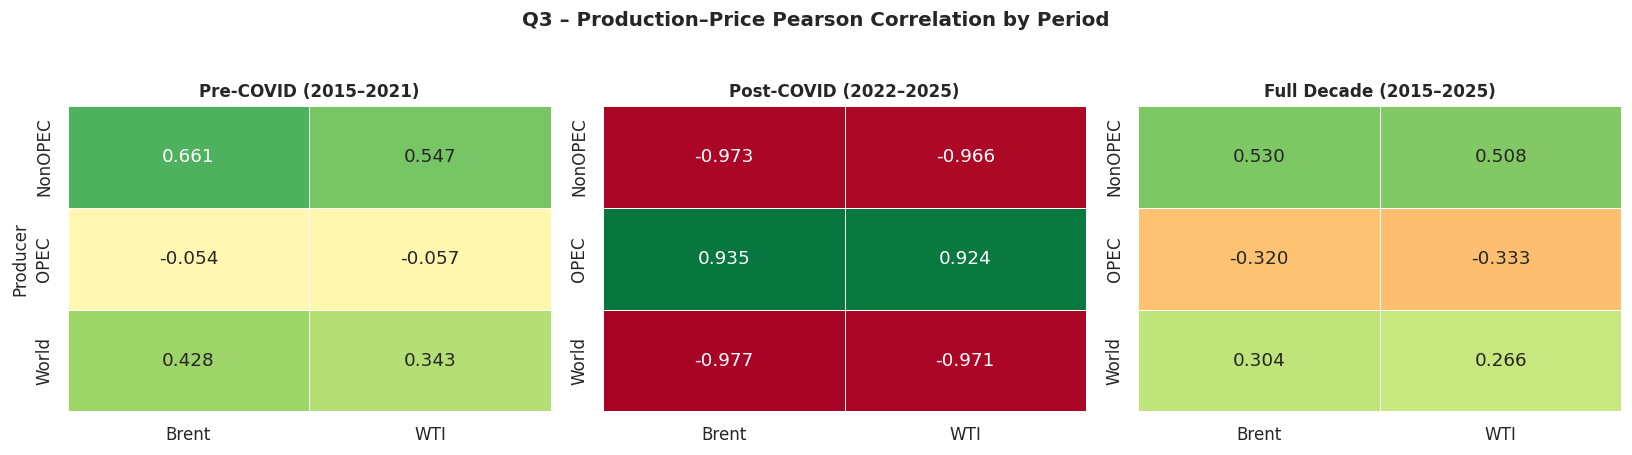

In [ ]:
# Heatmap — one per period for Brent price
def build_heatmap_df(period_df, label):
    rows = []
    for x in ["World_mbpd", "OPEC_mbpd", "NonOPEC_mbpd"]:
        for y in ["Avg_WTI_Price", "Avg_Brent_Price"]:
            r = period_df[x].corr(period_df[y])
            rows.append({"Producer": x.replace("_mbpd",""),
                         "Price":    y.replace("Avg_","").replace("_Price",""),
                         "r": r})
    return pd.DataFrame(rows).pivot(index="Producer", columns="Price", values="r")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ["Pre-COVID (2015–2021)", "Post-COVID (2022–2025)", "Full Decade (2015–2025)"]
dfs    = [pre, post, df]

for ax, title, d in zip(axes, titles, dfs):
    hm = build_heatmap_df(d, title)
    sns.heatmap(
        hm, ax=ax, annot=True, fmt=".3f",
        cmap="RdYlGn", center=0, vmin=-1, vmax=1,
        linewidths=0.5, cbar=False
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("" if ax != axes[0] else "Producer")

plt.suptitle("Q3 – Production–Price Pearson Correlation by Period",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

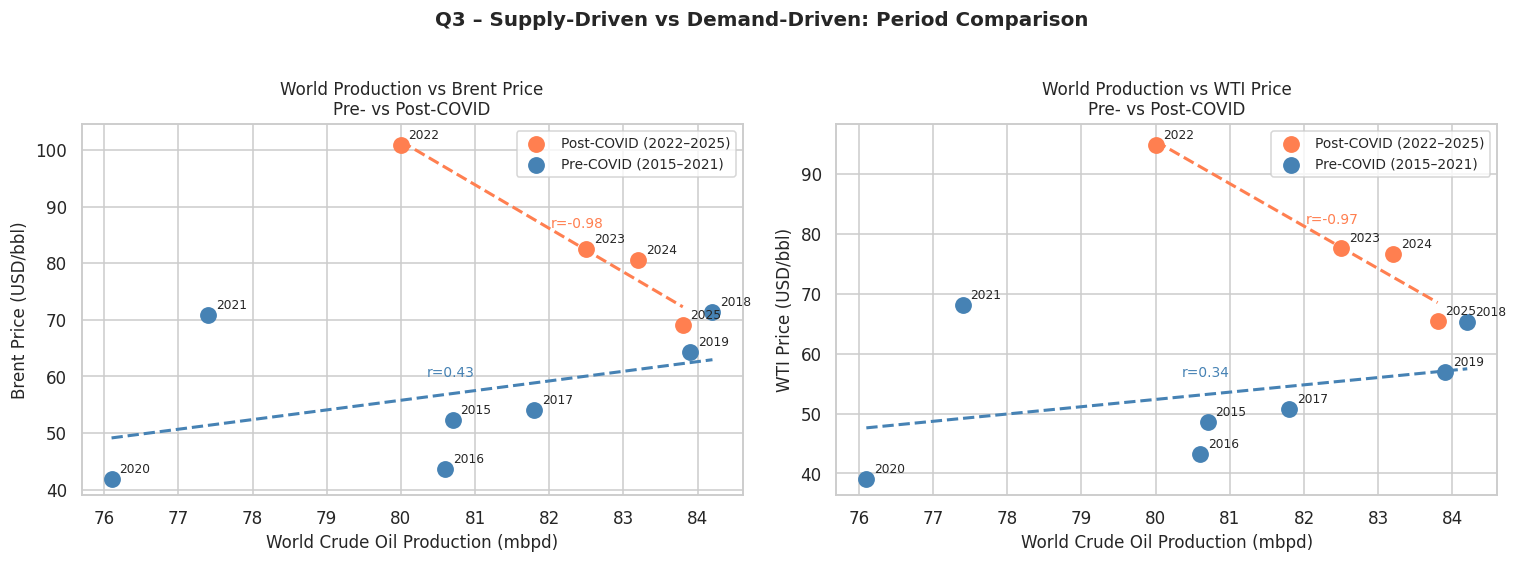

In [ ]:
# Scatter: World production vs Brent — colored by period
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"Pre-COVID (2015–2021)": "steelblue", "Post-COVID (2022–2025)": "coral"}

for ax, price_col, price_label in zip(
    axes,
    ["Avg_Brent_Price", "Avg_WTI_Price"],
    ["Brent", "WTI"]
):
    for period, sub in df.groupby("Period"):
        ax.scatter(
            sub["World_mbpd"], sub[price_col],
            color=colors[period], s=100, label=period, zorder=3
        )
        # Regression line per period
        m, b = np.polyfit(sub["World_mbpd"], sub[price_col], 1)
        x_line = np.linspace(sub["World_mbpd"].min(), sub["World_mbpd"].max(), 50)
        ax.plot(x_line, m*x_line + b, color=colors[period], lw=2, linestyle="--")
        r = sub["World_mbpd"].corr(sub[price_col])
        ax.text(
            sub["World_mbpd"].mean(),
            m * sub["World_mbpd"].mean() + b + 3,
            f"r={r:.2f}", color=colors[period], fontsize=9, ha="center"
        )

    # Year labels
    for _, row in df.iterrows():
        ax.annotate(str(int(row["Year"])),
                    (row["World_mbpd"], row[price_col]),
                    textcoords="offset points", xytext=(5, 4), fontsize=8)

    ax.set_title(f"World Production vs {price_label} Price\nPre- vs Post-COVID", fontsize=11)
    ax.set_xlabel("World Crude Oil Production (mbpd)")
    ax.set_ylabel(f"{price_label} Price (USD/bbl)")
    ax.legend(fontsize=9)

plt.suptitle("Q3 – Supply-Driven vs Demand-Driven: Period Comparison",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

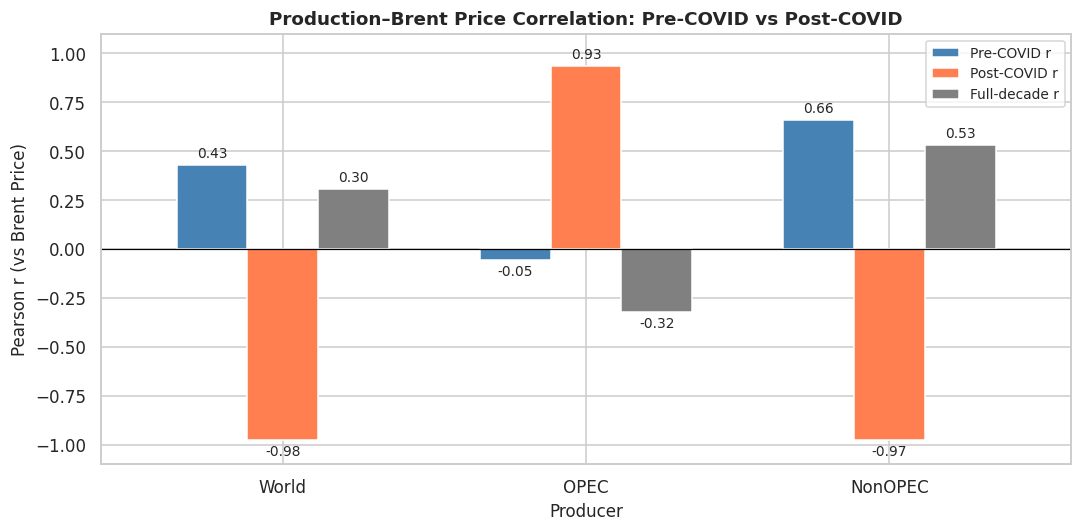

In [ ]:
# Final robust version
fig, ax = plt.subplots(figsize=(10, 5))

brent_rows = bar_data[bar_data["Price"].str.contains("brent", case=False, na=False)].copy()

if brent_rows.empty:
    ax.text(0.5, 0.5, "No Brent data found.\nCheck bar_data['Price'].unique()",
            ha="center", va="center", transform=ax.transAxes, fontsize=12, color="red")
else:
    brent_rows = brent_rows.set_index("Producer")[["Pre-COVID r", "Post-COVID r", "Full-decade r"]]
    brent_rows.plot(kind="bar", ax=ax, width=0.7,
                    color=["steelblue", "coral", "gray"],
                    edgecolor="white", rot=0)

    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel("Pearson r (vs Brent Price)")
    ax.set_title("Production–Brent Price Correlation: Pre-COVID vs Post-COVID",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

plt.tight_layout()
plt.show()

**Insight — Q3 (Supply vs Demand):**

| Period | World | OPEC | Non-OPEC | Dominant driver |
|---|---|---|---|---|
| Pre-COVID 2015–2021 | moderate positive | near-zero / weak negative | moderate positive | **Demand-led** — expansion cycle 2015-19, COVID dip 2020, sharp recovery 2021 |
| Post-COVID 2022–2025 | flips negative | flips positive | strongly negative | **Supply-managed** — Russia-Ukraine shock (2022) + OPEC strategic cuts |
| Full decade | weak / near-zero | near-zero / negative | moderate positive | Mixed — shocks cancel the signal |

**Key takeaways:**
- **Pre-COVID (2015–2021)**: the market was broadly demand-driven through 2019; the 2020 pandemic dip and 2021 sharp recovery are included in this window. Despite the COVID dip, the overall 2015–2021 correlation remains moderately positive as prices and output both rebounded. OPEC's near-zero correlation reflects their counter-cyclical supply management.
- **Post-COVID (2022–2025)**: the relationship shifts. The Russia-Ukraine supply disruption (2022) drove prices to a decade-high while Non-OPEC scrambled to fill the gap. OPEC strategic cuts kept their output falling even as prices rose, producing a *positive* OPEC-price correlation. By 2023–2025, prices moderated as supply normalised.
- **Caveat**: post-COVID has only 5 annual observations, so correlations are directionally informative rather than statistically conclusive.

---
## 7 — Summary Dashboard

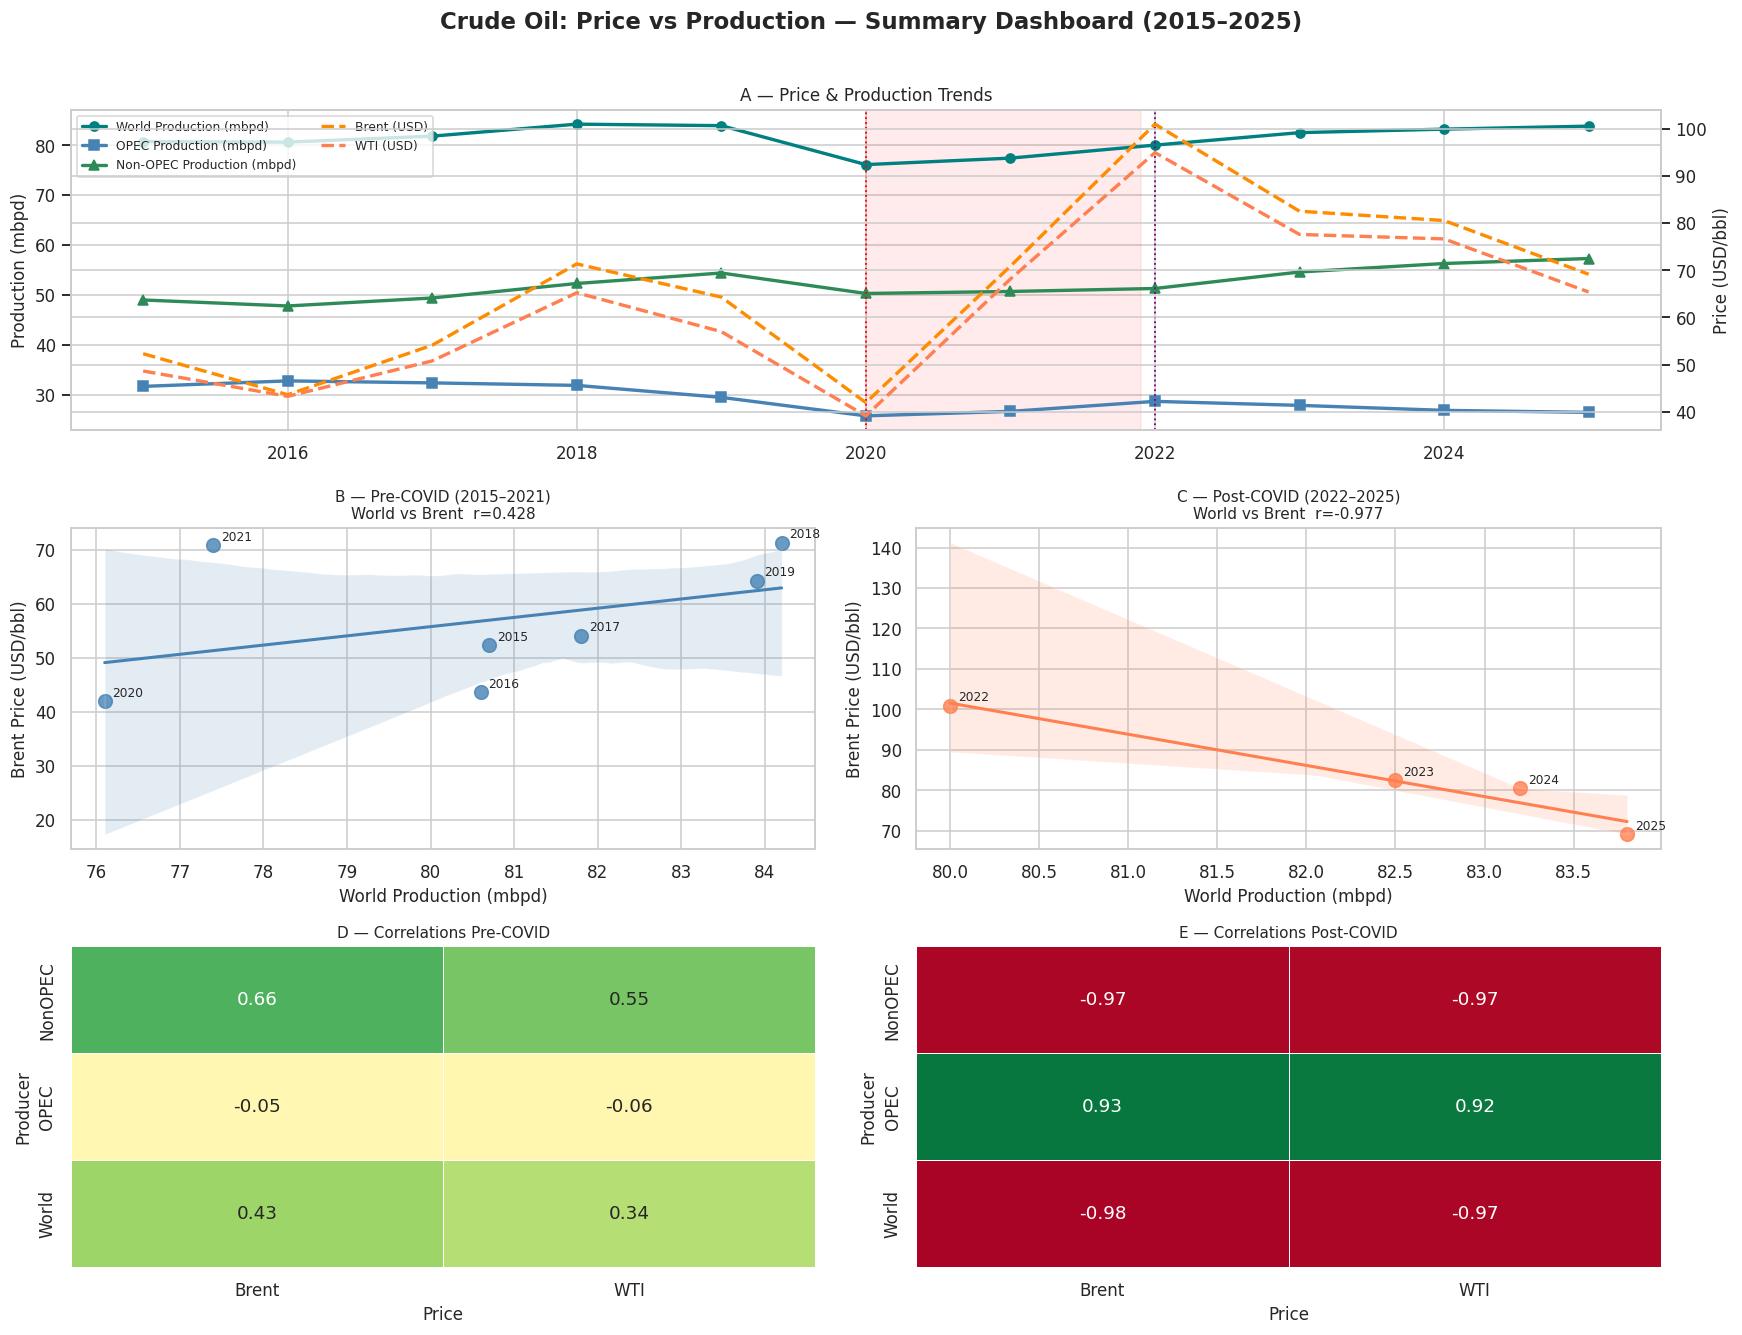

In [ ]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Crude Oil: Price vs Production — Summary Dashboard (2015–2025)",
             fontsize=15, fontweight="bold", y=1.01)

# ── Panel A: Dual-axis trend ──────────────────────────────────────────────────
ax_a = fig.add_subplot(3, 2, (1, 2))
ax_a.plot(df["Year"], df["World_mbpd"],   color="teal",      lw=2.2, marker="o", label="World Production (mbpd)")
ax_a.plot(df["Year"], df["OPEC_mbpd"],    color="steelblue", lw=2.2, marker="s", label="OPEC Production (mbpd)")
ax_a.plot(df["Year"], df["NonOPEC_mbpd"], color="seagreen",  lw=2.2, marker="^", label="Non-OPEC Production (mbpd)")
ax_a.set_ylabel("Production (mbpd)")
ax_b = ax_a.twinx()
ax_b.plot(df["Year"], df["Avg_Brent_Price"], color="darkorange", lw=2.2, linestyle="--", label="Brent (USD)")
ax_b.plot(df["Year"], df["Avg_WTI_Price"],   color="coral",      lw=2.2, linestyle="--", label="WTI (USD)")
ax_b.set_ylabel("Price (USD/bbl)")
ax_a.axvspan(2020, 2021.9, alpha=0.08, color="red")
ax_a.axvline(2020, color="red", lw=1.2, linestyle=":")
ax_a.axvline(2022, color="purple", lw=1.2, linestyle=":")
l1, lbl1 = ax_a.get_legend_handles_labels()
l2, lbl2 = ax_b.get_legend_handles_labels()
ax_a.legend(l1+l2, lbl1+lbl2, loc="upper left", fontsize=8, ncol=2)
ax_a.set_title("A — Price & Production Trends", fontsize=11)

# ── Panel B: Pre-COVID scatter ────────────────────────────────────────────────
ax_c = fig.add_subplot(3, 2, 3)
sns.regplot(data=pre, x="World_mbpd", y="Avg_Brent_Price", ax=ax_c,
            scatter_kws={"color":"steelblue","s":80},
            line_kws={"color":"steelblue","lw":2})
for _, row in pre.iterrows():
    ax_c.annotate(str(int(row["Year"])), (row["World_mbpd"], row["Avg_Brent_Price"]),
                  textcoords="offset points", xytext=(5,3), fontsize=8)
r_pre = pre["World_mbpd"].corr(pre["Avg_Brent_Price"])
ax_c.set_title(f"B — Pre-COVID (2015–2021)\nWorld vs Brent  r={r_pre:.3f}", fontsize=10)
ax_c.set_xlabel("World Production (mbpd)"); ax_c.set_ylabel("Brent Price (USD/bbl)")

# ── Panel C: Post-COVID scatter ───────────────────────────────────────────────
ax_d = fig.add_subplot(3, 2, 4)
sns.regplot(data=post, x="World_mbpd", y="Avg_Brent_Price", ax=ax_d,
            scatter_kws={"color":"coral","s":80},
            line_kws={"color":"coral","lw":2})
for _, row in post.iterrows():
    ax_d.annotate(str(int(row["Year"])), (row["World_mbpd"], row["Avg_Brent_Price"]),
                  textcoords="offset points", xytext=(5,3), fontsize=8)
r_post = post["World_mbpd"].corr(post["Avg_Brent_Price"])
ax_d.set_title(f"C — Post-COVID (2022–2025)\nWorld vs Brent  r={r_post:.3f}", fontsize=10)
ax_d.set_xlabel("World Production (mbpd)"); ax_d.set_ylabel("Brent Price (USD/bbl)")

# ── Panel D: Correlation heatmap – Pre-COVID ──────────────────────────────────
ax_e = fig.add_subplot(3, 2, 5)
hm_pre = build_heatmap_df(pre, "pre")
sns.heatmap(hm_pre, ax=ax_e, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar=False)
ax_e.set_title("D — Correlations Pre-COVID", fontsize=10)

# ── Panel E: Correlation heatmap – Post-COVID ─────────────────────────────────
ax_f = fig.add_subplot(3, 2, 6)
hm_post = build_heatmap_df(post, "post")
sns.heatmap(hm_post, ax=ax_f, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar=False)
ax_f.set_title("E — Correlations Post-COVID", fontsize=10)

plt.tight_layout()
plt.show()

---
## 8 — Final Conclusions

### Research Question: Supply-Driven vs Demand-Driven?

**The answer depends heavily on the time period:**

---

**Pre-COVID (2015–2021) → Demand-Driven**
- Global production and prices rose together (positive correlation), consistent with demand expansion pulling both.
- Non-OPEC producers (especially US shale) ramped output as prices rose — price-responsive behaviour.
- OPEC's near-zero correlation reflects their counter-cyclical role: they reduced output when Non-OPEC flooded the market (2016 price war), then cut to support prices (2016–2019 Vienna Agreement).

---

**Post-COVID (2022–2025) → Supply-Shock Driven**
- 2020 demand collapse sent prices and production down simultaneously — a classic demand shock that nevertheless produced a *negative* production-price relationship when supply recovery lagged.
- 2022 Russia-Ukraine supply disruption drove prices up while Non-OPEC scrambled and OPEC strategically cut, breaking any simple supply → price link.
- The correlation sign change (World/Non-OPEC flipping negative; OPEC flipping positive) is a fingerprint of a market dominated by supply disruptions and geopolitical constraints rather than demand cycles.

---

**Broader takeaway:**
A single decade-level correlation near zero is *not* because supply and price are unrelated — it is because two opposing regimes (demand-driven expansion pre-2022, supply-shock disruption post-2022) partially cancel each other. This underscores why **structural break analysis** (splitting at COVID) reveals a richer story than pooled regression, and why oil prices remain notoriously difficult to model with production data alone.

# WTI/Inventory/MEMP: 2yrs trend

Dashboard: WTI Crude Oil Price, EIA Petroleum Inventory, ISM Manufacturing Employment (USMEMP) 

- WTI: Daily (via yfinance)
- Petroleum Inventory: Weekly (via EIA API - STEO or public dataset)
- USMEMP: Monthly (via FRED API)

Setup:
- EIA API Key: https://www.eia.gov/opendata/register.php  (free)
- FRED API Key: https://fred.stlouisfed.org/docs/api/api_key.html (free)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import yfinance as yf
from fredapi import Fred
import requests
import plotly.graph_objects as go
import talib
from datetime import datetime, timedelta
EIA_API_KEY  = "QbYLCizQ70C4NaBiKLQ6h2kuGwdOntLEL6adRznd"
FRED_API_KEY = "1a98920cbffd6466e68c66d597ae2cfe"
END_DATE  = datetime.today()
START_DATE= END_DATE - timedelta(days=730)
START_STR = START_DATE.strftime("%Y-%m-%d")
END_STR   = END_DATE.strftime("%Y-%m-%d")
# --------------
# yfinance: WTI Crude Oil spot daily price (CL=F futures).
# --------------
def get_wti_daily(start: str, end: str) -> pd.DataFrame:
    ticker = yf.Ticker("CL=F")
    df = ticker.history(start=start, end=end, interval="1d")
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df = df.rename(columns={"Close": "WTI_Price"})
    df.index = df.index.tz_localize(None)
    return df
# --------------
# EIA weekly inventory series: PET.WCSSTUS1.W (US Commercial Crude Oil + SPR, thousand barrels) 
      # Alternative series id: PET.WTTSTUS1.W (total petroleum stocks)
# --------------
def get_eia_petroleum_inventory(start: str, end: str, api_key: str) -> pd.Series:
    series_id = "PET.WTTSTUS1.W"  # Total petroleum stocks, all countries
    url = (
        f"https://api.eia.gov/v2/seriesid/{series_id}"
        f"?api_key={api_key}&frequency=weekly"
        f"&start={start}&end={end}&sort[0][column]=period&sort[0][direction]=asc"
        f"&offset=0&length=5000"
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()

    rows = data["response"]["data"]
    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["period"])
    df = df.set_index("date").sort_index()
    series = pd.to_numeric(df["value"], errors="coerce").rename("Petroleum_Inventory_Mbbl")
    series = series.diff().dropna()
    return series
# --------------
# fredapi: monthly series id - Manufacturing Employment (MANEMP), thousands
# --------------
def get_ism_employment_fred(start: str, end: str, api_key: str) -> pd.Series:
    fred = Fred(api_key=FRED_API_KEY)
    ism_emp = fred.get_series('MANEMP', observation_start=start)
    ism_emp = ism_emp.rename("ISM_Employment")
    ism_emp.index = pd.to_datetime(ism_emp.index)
    return ism_emp
# --------------
# process data
# --------------
def process_data(wti: pd.DataFrame, inventory: pd.Series, ism: pd.Series):
    """Align all series to a common daily index via forward-fill."""
    # Build a full daily date range
    idx = pd.date_range(start=START_STR, end=END_STR, freq="B")  # business days

    wti_reindexed       = wti.reindex(idx, method="ffill")
    inventory_reindexed = inventory.reindex(idx, method="ffill")
    ism_reindexed       = ism.reindex(idx, method="ffill")

    # ── Combine: start with WTI columns, then append the two Series ──
    df = wti_reindexed.copy()                                    # Open, High, Low, WTI_Price(Close), Volume
    df["Petroleum_Inventory_Mbbl"] = inventory_reindexed.values
    df["ISM_Employment"]           = ism_reindexed.values
    df.dropna(how="all", inplace=True)
    return df

# ─────────────────────────────────────────────
# MAIN
if __name__ == "__main__":
    print("Fetching WTI daily prices …")
    wti = get_wti_daily(START_STR, END_STR)

    print("Fetching EIA petroleum inventory …")
    inventory = get_eia_petroleum_inventory(START_STR, END_STR, EIA_API_KEY)

    print("Fetching ISM Employment (FRED) …")
    ism = get_ism_employment_fred(START_STR, END_STR, FRED_API_KEY)

    print("Processing …")
    df = process_data(wti, inventory, ism)

    print(df.tail())

Fetching WTI daily prices …
Fetching EIA petroleum inventory …
Fetching ISM Employment (FRED) …
Processing …
                 Open       High        Low  WTI_Price  Volume  \
2026-02-19  65.099998  66.900002  64.879997  66.430000  113408   
2026-02-20  66.669998  67.050003  65.940002  66.389999  351351   
2026-02-23  65.889999  67.279999  65.379997  66.309998  270365   
2026-02-24  66.309998  67.150002  65.550003  65.629997  270365   
2026-02-25  66.309998  67.150002  65.550003  65.629997  270365   

            Petroleum_Inventory_Mbbl  ISM_Employment  
2026-02-19                  -18851.0         12590.0  
2026-02-20                  -18851.0         12590.0  
2026-02-23                  -18851.0         12590.0  
2026-02-24                  -18851.0         12590.0  
2026-02-25                  -18851.0         12590.0  


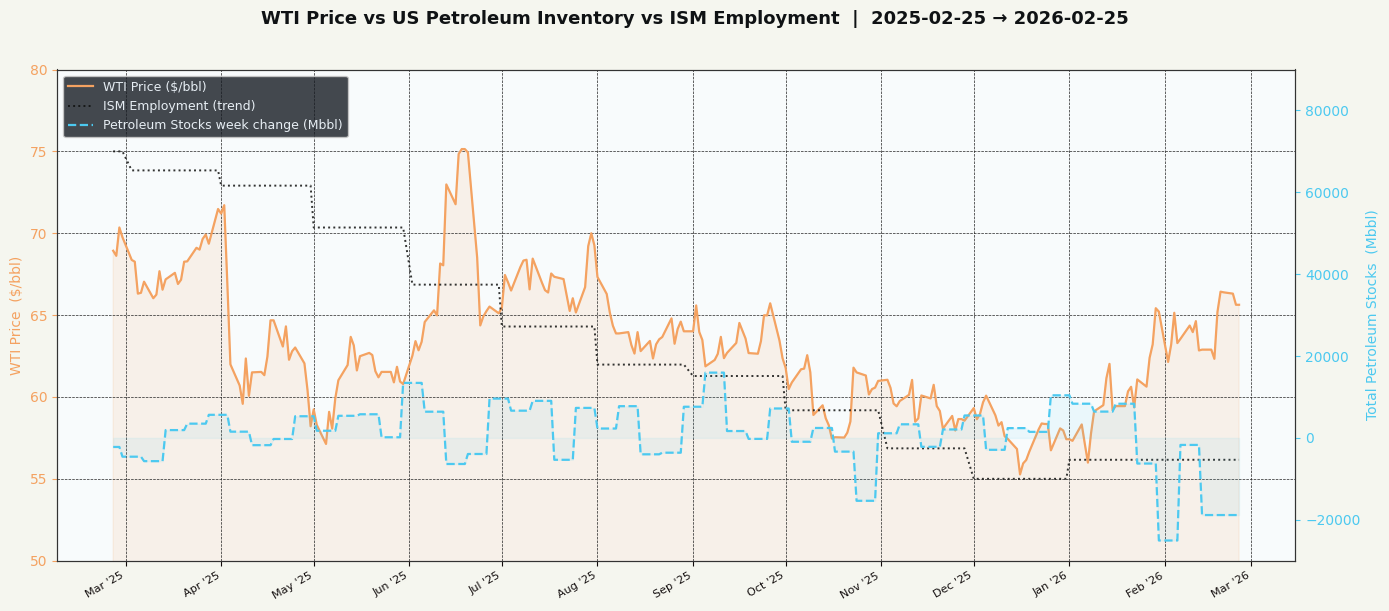

In [ ]:
def plot_dashboard(df: pd.DataFrame):
    fig, ax1 = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("#f5f6ef")
    ax1.set_facecolor("#f8fbfcff")

    # ── WTI Price: Left axis ──
    color_wti = "#f4a261"
    wti = df["WTI_Price"].dropna()
    ax1.plot(wti.index, wti.values, color=color_wti, linewidth=1.6, label="WTI Price ($/bbl)")
    ax1.fill_between(wti.index, wti.values, alpha=0.12, color=color_wti)
    ax1.set_ylim(50, 80)
    ax1.set_ylabel("WTI Price  ($/bbl)", color=color_wti, fontsize=10)
    ax1.tick_params(axis="y", colors=color_wti)
    ax1.tick_params(axis="x", colors="#110a0a")

    # ── Petroleum Inventory: Right axis ──
    color_inv = "#4cc9f0"
    ax2 = ax1.twinx()
    inv = df["Petroleum_Inventory_Mbbl"].dropna()
    ax2.plot(inv.index, inv.values, color=color_inv, linewidth=1.6,
             linestyle="--", label="Petroleum Stocks week change (Mbbl)")
    ax2.fill_between(inv.index, inv.values, alpha=0.08, color=color_inv)
    ax2.set_ylim(-30000, 90000)
    ax2.set_ylabel("Total Petroleum Stocks  (Mbbl)", color=color_inv, fontsize=10)
    ax2.tick_params(axis="y", colors=color_inv)

    # ── ISM Employment: Normalized trend on left axis (no extra axis) ──
    color_ism = "#0f100f"
    ism = df["ISM_Employment"].dropna()
    # Normalize ISM to the WTI axis range [50, 80] so it appears as a pure trend overlay
    ism_min, ism_max = ism.min(), ism.max()
    wti_lo, wti_hi = 55, 75
    ism_norm = (ism - ism_min) / (ism_max - ism_min) * (wti_hi - wti_lo) + wti_lo
    ax1.plot(ism_norm.index, ism_norm.values, color=color_ism, linewidth=1.4,
             linestyle=":", alpha=0.85, label="ISM Employment (trend)")

    # ── Shared formatting ──
    for spine in ax1.spines.values():
        spine.set_edgecolor("#333333")
    for spine in ax2.spines.values():
        spine.set_edgecolor("#333333")
    ax1.grid(True, color="#222222", linewidth=0.5, linestyle="--")

    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8, color="#140f0f")

    # ── Legend (combine all three) ──
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               facecolor="#161b22", labelcolor="#e6edf3",
               fontsize=9, loc="upper left", framealpha=0.8)

    fig.suptitle(
        f"WTI Price vs US Petroleum Inventory vs ISM Employment  |  {START_STR} → {END_STR}",
        color="#0f1214", fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()
plot_dashboard(df)

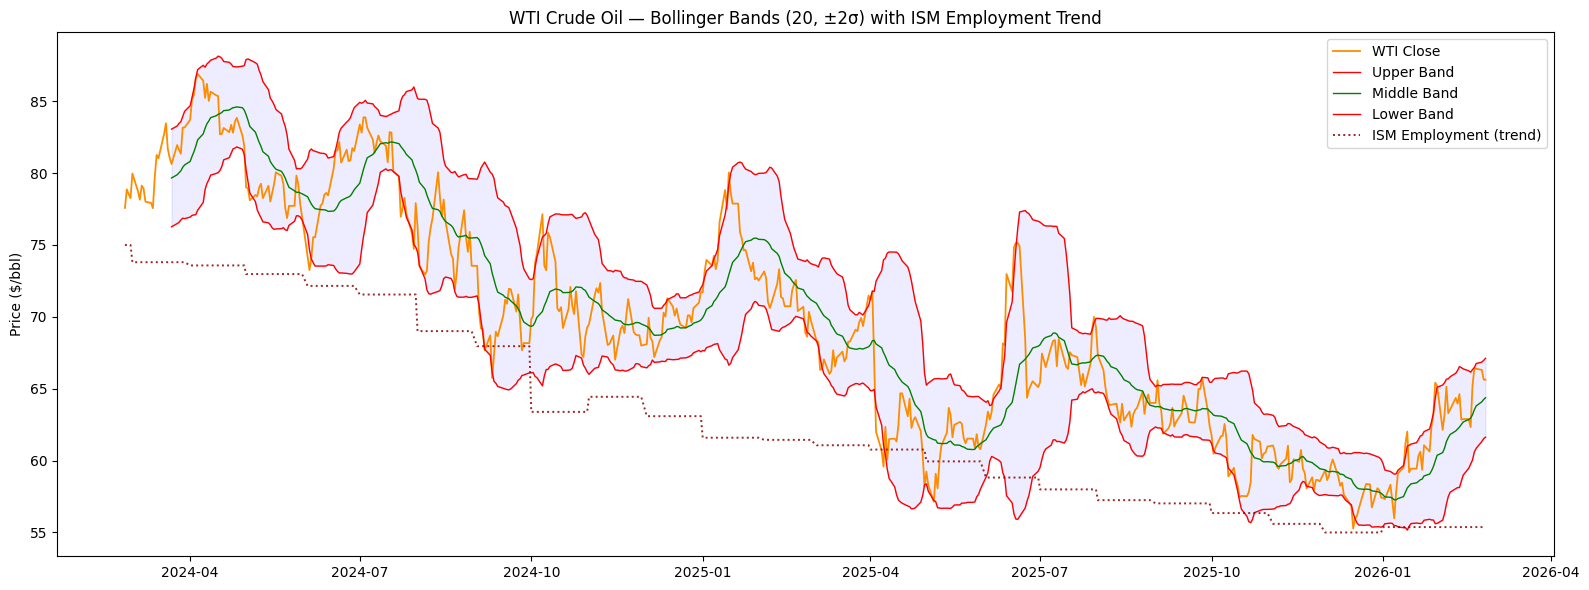

In [ ]:
# Bollinger Bands + ISM
upper, mid, lower = talib.BBANDS(df['WTI_Price'],
                                  nbdevup=2,
                                  nbdevdn=2,
                                  timeperiod=20)

fig, ax1 = plt.subplots(figsize=(16, 6))

# ── Bollinger Bands + WTI price on ax1 ──
ax1.plot(df['WTI_Price'], label='WTI Close',   color='darkorange', linewidth=1.3)
ax1.plot(upper,           label='Upper Band',  color='red',        linewidth=1.0)
ax1.plot(mid,             label='Middle Band', color='green',      linewidth=1.0)
ax1.plot(lower,           label='Lower Band',  color='red',        linewidth=1.0)
ax1.fill_between(df.index, upper, lower, alpha=0.07, color='blue')
ax1.set_ylabel('Price ($/bbl)')

# ── ISM Employment: normalized trend overlay on ax1 (no extra axis) ──
color_ism = "#8B0000"                          # dark red — visible against the dark bands
ism = df["ISM_Employment"].dropna()
ism_min, ism_max = ism.min(), ism.max()
wti_lo, wti_hi   = 55, 75                      # normalize into the visible WTI price range
ism_norm = (ism - ism_min) / (ism_max - ism_min) * (wti_hi - wti_lo) + wti_lo
ax1.plot(ism_norm.index, ism_norm.values,
         color=color_ism, linewidth=1.4, linestyle=":", alpha=0.85,
         label="ISM Employment (trend)")

ax1.set_title('WTI Crude Oil — Bollinger Bands (20, ±2σ) with ISM Employment Trend')
ax1.legend()
plt.tight_layout()
plt.show()

# BoW Spread/Z-score Strategy

Source: **Quantitative research project: Implementation of a mean-reversion strategy on energy futures spreads** by Augustin Debove

This repository contains a systematic algorithmic trading strategy exploiting the statistical co-integration between **WTI (NYMEX)** and **Brent (ICE)** Crude Oil futures. The project demonstrates a full quantitative pipeline, from raw data ingestion and synchronization to risk-adjusted performance analysis.

#### Technical Highlights
* **Data Engineering and Synchronization:** The framework implements a custom alignment logic to handle asynchronous trading calendars. By reconciling NYMEX and ICE exchange holidays, the backtest eliminates data stale-pricing bias.
* **Mean-Reversion Engine:** Signals are generated via a dynamic Z-Score calculated on a rolling lookback window. This normalizes the spread volatility and identifies statistically significant entry and exit points.
* **Robustness vs. Overfitting:** Parameter selection (window size and thresholds) was conducted using stability cluster analysis rather than raw historical optimization. This ensures higher generalization capabilities on unseen data.
* **Risk Management:** A hard statistical stop-loss is integrated at $|Z| > 3.5$ to protect the portfolio against structural regime shifts or geopolitical shocks.

>> Out-of-Sample Results (Jan 2024 - Feb 2026)
The model was validated on strictly unseen data to confirm its predictive power:
* **Sharpe Ratio:** 2.17
* **Net PnL per Barrel:** $14.60 (inclusive of estimated transaction costs)
* **Execution Logic:** Entry at $|Z| > 1.9$, Mean-reversion exit at $|Z| < 0.5$.

🚀 WTI / Brent Stat Arb – DAILY SIGNAL + SPREAD & Z-SCORE CHART
   Run time: 2026-02-26 16:13:17


/tmp/ipykernel_5595/1698083177.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(tickers, start=START_HISTORY, progress=False)['Close']


📊 Data: 2023-01-03 → 2026-02-26 (792 days)

🔍 Optimizing parameters (grid search)...
✅ Best params (Sharpe-optimized):
   Window    = 30 days
   Z-Entry   = ±2.00
   Sharpe    = 1.88

📍 TODAY'S SIGNAL
   Date          : 2026-02-26
   WTI           :    65.57 USD
   Brent         :    70.88 USD
   Spread        :   -5.310
   Z-Score       :   -1.175 
   Rules         : Entry ±2.00 | Exit |Z|<0.5 | Hard stop |Z|>4.0
   Position      : ⚪ FLAT   →  No position (waiting)


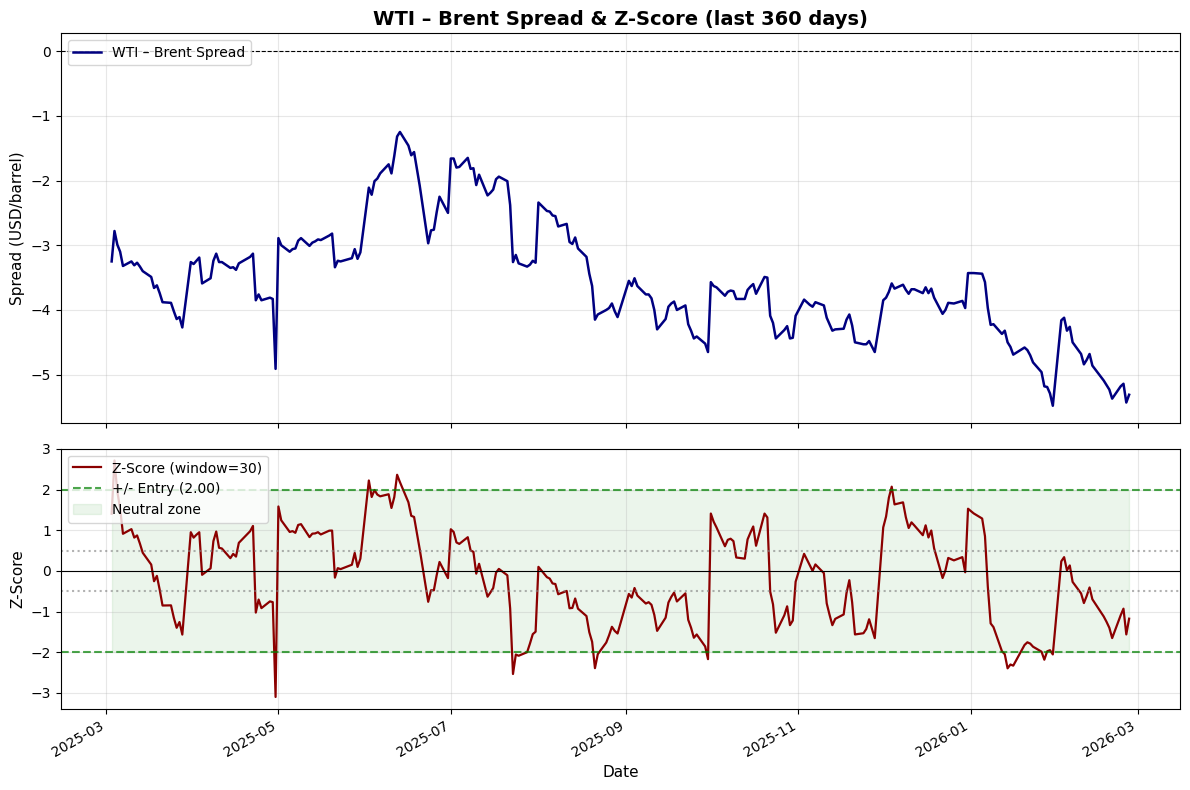

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ====================== WTI / BRENT DAILY SIGNAL MONITOR + VISUALS ======================
print("="*80)
print("🚀 WTI / Brent Stat Arb – DAILY SIGNAL + SPREAD & Z-SCORE CHART")
print(f"   Run time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

# ========================= CONFIG =========================
START_HISTORY     = "2023-01-01"           # for optimization
PLOT_LOOKBACK_DAYS = 360                   # show last ~6 months in chart
TRANSACTION_COST  = 0.05
# =========================================================

# 1. Load latest data
tickers = ['CL=F', 'BZ=F']
raw = yf.download(tickers, start=START_HISTORY, progress=False)['Close']

data = pd.DataFrame()
data['WTI']   = raw['CL=F']
data['Brent'] = raw['BZ=F']
data.dropna(inplace=True)

if len(data) < 100:
    print("❌ Not enough aligned data. Check connection or futures symbols.")
    raise SystemExit

print(f"📊 Data: {data.index[0].date()} → {data.index[-1].date()} ({len(data):,} days)\n")

data['spread'] = data['WTI'] - data['Brent']
data['spread_diff'] = data['spread'].diff()

# ====================== OPTIMIZATION ======================
print("🔍 Optimizing parameters (grid search)...")

profit_dict = {}
sharpe_dict = {}

for window in range(5, 51, 5):
    mean_roll = data['spread'].rolling(window).mean()
    std_roll  = data['spread'].rolling(window).std()
    
    for z_raw in np.arange(0.5, 4.01, 0.1):           # coarser grid for speed
        z = round(z_raw, 2)
        
        z_score_temp = (data['spread'] - mean_roll) / std_roll
        
        signal = pd.Series(np.nan, index=data.index)
        signal.loc[z_score_temp < -z] = 1
        signal.loc[z_score_temp >  z] = -1
        signal.loc[z_score_temp.abs() < 0.5] = 0
        signal.loc[z_score_temp.abs() > 4.0] = 0
        
        position = signal.ffill().fillna(0)
        
        trades = position.diff().abs()
        costs  = trades * TRANSACTION_COST
        
        strat_ret = (position.shift(1) * data['spread_diff']) - costs
        
        profit_dict[(window, z)] = strat_ret.sum()
        sharpe = (strat_ret.mean() / strat_ret.std() * np.sqrt(252)) if strat_ret.std() != 0 else 0
        sharpe_dict[(window, z)] = sharpe

# Build results
results = pd.DataFrame(
    [(w, z, p, sharpe_dict[(w, z)]) for (w, z), p in profit_dict.items()],
    columns=['Window', 'Z_Entry', 'Total_Profit', 'Sharpe']
)

best_row   = results.loc[results['Sharpe'].idxmax()]
best_window = int(best_row['Window'])
best_z      = best_row['Z_Entry']

print(f"✅ Best params (Sharpe-optimized):")
print(f"   Window    = {best_window} days")
print(f"   Z-Entry   = ±{best_z:.2f}")
print(f"   Sharpe    = {best_row['Sharpe']:.2f}\n")

# ====================== LIVE SIGNAL + Z-SCORE ======================
mean_now = data['spread'].rolling(best_window).mean()
std_now  = data['spread'].rolling(best_window).std()
data['z_score'] = (data['spread'] - mean_now) / std_now

# Signal logic (same as optimization)
signal = pd.Series(np.nan, index=data.index)
signal.loc[data['z_score'] < -best_z] = 1
signal.loc[data['z_score'] >  best_z] = -1
signal.loc[data['z_score'].abs() < 0.5] = 0
signal.loc[data['z_score'].abs() > 4.0] = 0

data['position'] = signal.ffill().fillna(0)

# Today's values
today   = data.index[-1]
wti     = data['WTI'].iloc[-1]
brent   = data['Brent'].iloc[-1]
spread  = data['spread'].iloc[-1]
z_today = data['z_score'].iloc[-1]
pos     = data['position'].iloc[-1]

print("📍 TODAY'S SIGNAL")
print(f"   Date          : {today.strftime('%Y-%m-%d')}")
print(f"   WTI           : {wti:8.2f} USD")
print(f"   Brent         : {brent:8.2f} USD")
print(f"   Spread        : {spread:+8.3f}")
print(f"   Z-Score       : {z_today:+8.3f}", "  ← EXTREME" if abs(z_today) > 3 else "")
print(f"   Rules         : Entry ±{best_z:.2f} | Exit |Z|<0.5 | Hard stop |Z|>4.0")
print(f"   Position      : ", end="")
if pos == 1:    print("🟢 LONG SPREAD   (Buy WTI / Sell Brent)")
elif pos == -1: print("🔴 SHORT SPREAD  (Sell WTI / Buy Brent)")
else:           print("⚪ FLAT   →  No position (waiting)")
print("="*80)

# ====================== VISUALIZATION ======================
# Filter recent data for plot clarity
plot_start = today - timedelta(days=PLOT_LOOKBACK_DAYS)
plot_data  = data.loc[plot_start:].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 2]})

# --- Spread (top) ---
ax1.plot(plot_data.index, plot_data['spread'], color='navy', linewidth=1.8, label='WTI – Brent Spread')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title(f"WTI – Brent Spread & Z-Score (last {PLOT_LOOKBACK_DAYS} days)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Spread (USD/barrel)", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# --- Z-Score (bottom) ---
ax2.plot(plot_data.index, plot_data['z_score'], color='darkred', linewidth=1.6, label=f'Z-Score (window={best_window})')
ax2.axhline( best_z, color='green', linestyle='--', alpha=0.7, label=f'+/- Entry ({best_z:.2f})')
ax2.axhline(-best_z, color='green', linestyle='--', alpha=0.7)
ax2.axhline( 0.5,   color='gray', linestyle=':', alpha=0.6)
ax2.axhline(-0.5,   color='gray', linestyle=':', alpha=0.6)
ax2.axhline( 0,     color='black', linewidth=0.8)

ax2.fill_between(plot_data.index, -best_z, best_z, color='green', alpha=0.08, label='Neutral zone')
ax2.set_ylabel("Z-Score", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

# Formatting
plt.xlabel("Date", fontsize=11)
fig.autofmt_xdate()           # nice date labels
plt.tight_layout()
plt.show()

# Optional: save to file for records/alerts
# fig.savefig(f"wti_brent_monitor_{today.strftime('%Y%m%d')}.png", dpi=120, bbox_inches='tight')

# 模型预测:3ML + 4Stochastic

**3 ML模型:随机森林/支持向量回归/简单神经网络**

Input: 
- WTI oil price data (yFinance).
- Builds features from historical prices (lags, moving averages, volatility).

Train three models (Machine Learning): 
- Random Forest, Support Vector Regression, and a Small(Simple) Neural Network.

Output:
- Evaluates them on a held-out test period and prints metrics (MAE, RMSE, R²).
  - MAE: Mean Absolute Error 平均绝对误差
  - RMSE: Root Mean Squared Error 均方根误差
- Prints a one-step-ahead forecast for the next trading day.
- Draw actual vs predicted lines

**4 Stochastic models (Closed-form)**

Input: 
- **Interest rates**: Daily 10-year US Treasury rates from FRED

| Model | Description | SDE | Parameters |
|-------|-------------|-----|------------|
| 1. GBM (Gabillon) | Geometric Brownian Motion | dS = μ·Sₜ·dt + σ·Sₜ·dWₜ | δ |
| 2. OU (Schwartz) | Mean-reverting log process | dS = θ(μ − ln S)·dt + σ·S·dWₜ | θ, α, σ |
| 3. Modified Bessel | Square-root with nonlinear vol | dS = a·√S·dt + σ·S^(3/4)·dWₜ | a, σ |
| 4. Modified CIR | CIR drift with ¾ volatility | dS = (a·√S + b·S)·dt + σ·S^(3/4)·dWₜ | a, b, σ |

Each model provides an **analytical expression** for futures prices under deterministic interest rate assumptions.

 === Oil Price Prediction App (ML + Stochastic) === 
Fetching data for CL=F from 2021-02-27 to 2026-02-26...
Downloaded 1256 records.
Fetching 10-yr Treasury rates from FRED (DGS10)...
  Retrieved 1302 Treasury rate observations.

Train samples: 988, Test samples: 248
Features: ['close_lag_1', 'close_lag_5', 'close_lag_10', 'sma_5', 'sma_20', 'volatility_10', 'range_5']

ML Model performance (test set):
  Random Forest: MAE=2.10, RMSE=2.74, R²=0.4830
  Support Vector Regression: MAE=2.53, RMSE=3.43, R²=0.1921
  Neural Network: MAE=1.93, RMSE=2.74, R²=0.4848
Best ML model by R²: Neural Network (R²=0.4848)

--- ML Models: Next Trading Day Forecast ---
  Random Forest: $65.57 USD
  Support Vector Regression: $65.87 USD
  Neural Network: $67.46 USD


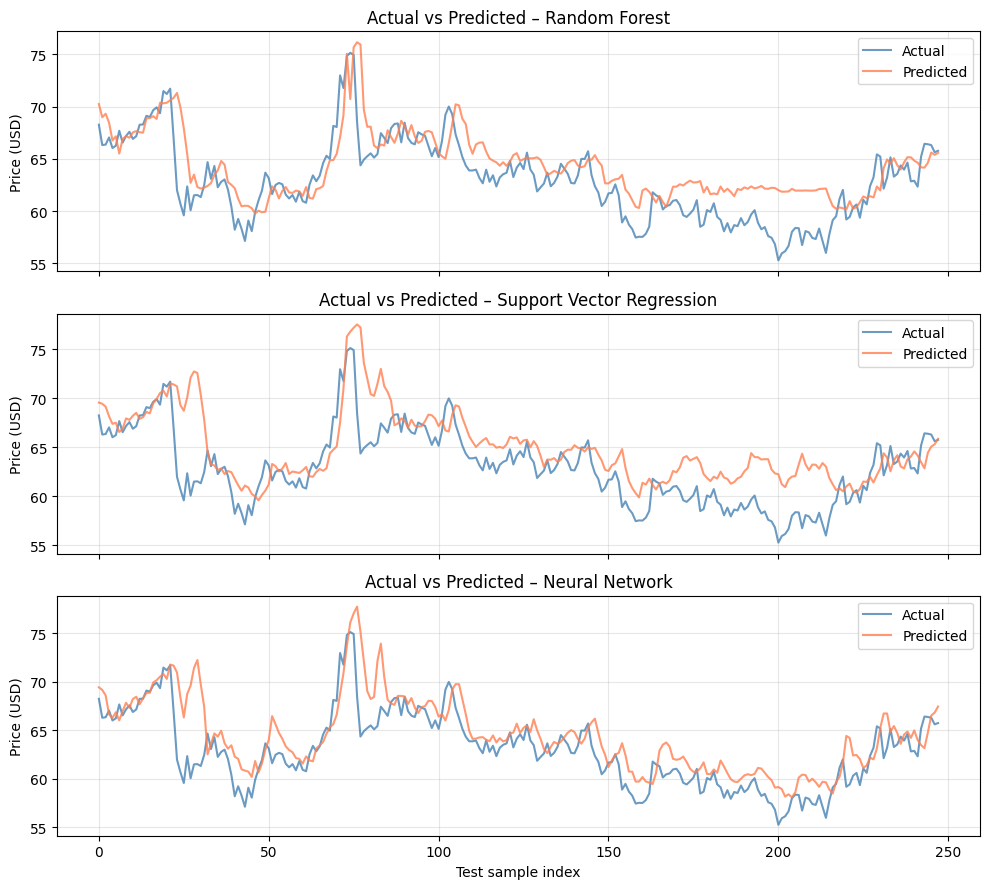


Stochastic Model performance (test set, one-step-ahead walk-forward):
  GBM: MAE=0.97, RMSE=1.33, R²=0.8822
  OU: MAE=0.97, RMSE=1.33, R²=0.8810
  CEV: MAE=0.97, RMSE=1.33, R²=0.8822
  CIR¾: MAE=0.97, RMSE=1.34, R²=0.8805
Best Stochastic model by R²: GBM – Geometric Brownian Motion (R²=0.8822)

--- Stochastic Models: Next Trading Day Forecast ---
  GBM  (Geometric Brownian Motion)       : $65.75 USD
  OU   (Mean-Reverting Log Process)       : $65.86 USD
  CEV  (Square-Root Nonlinear Vol, 3/2)   : $65.76 USD
  CIR¾ (CIR Drift, ¾ Vol)                 : $65.88 USD


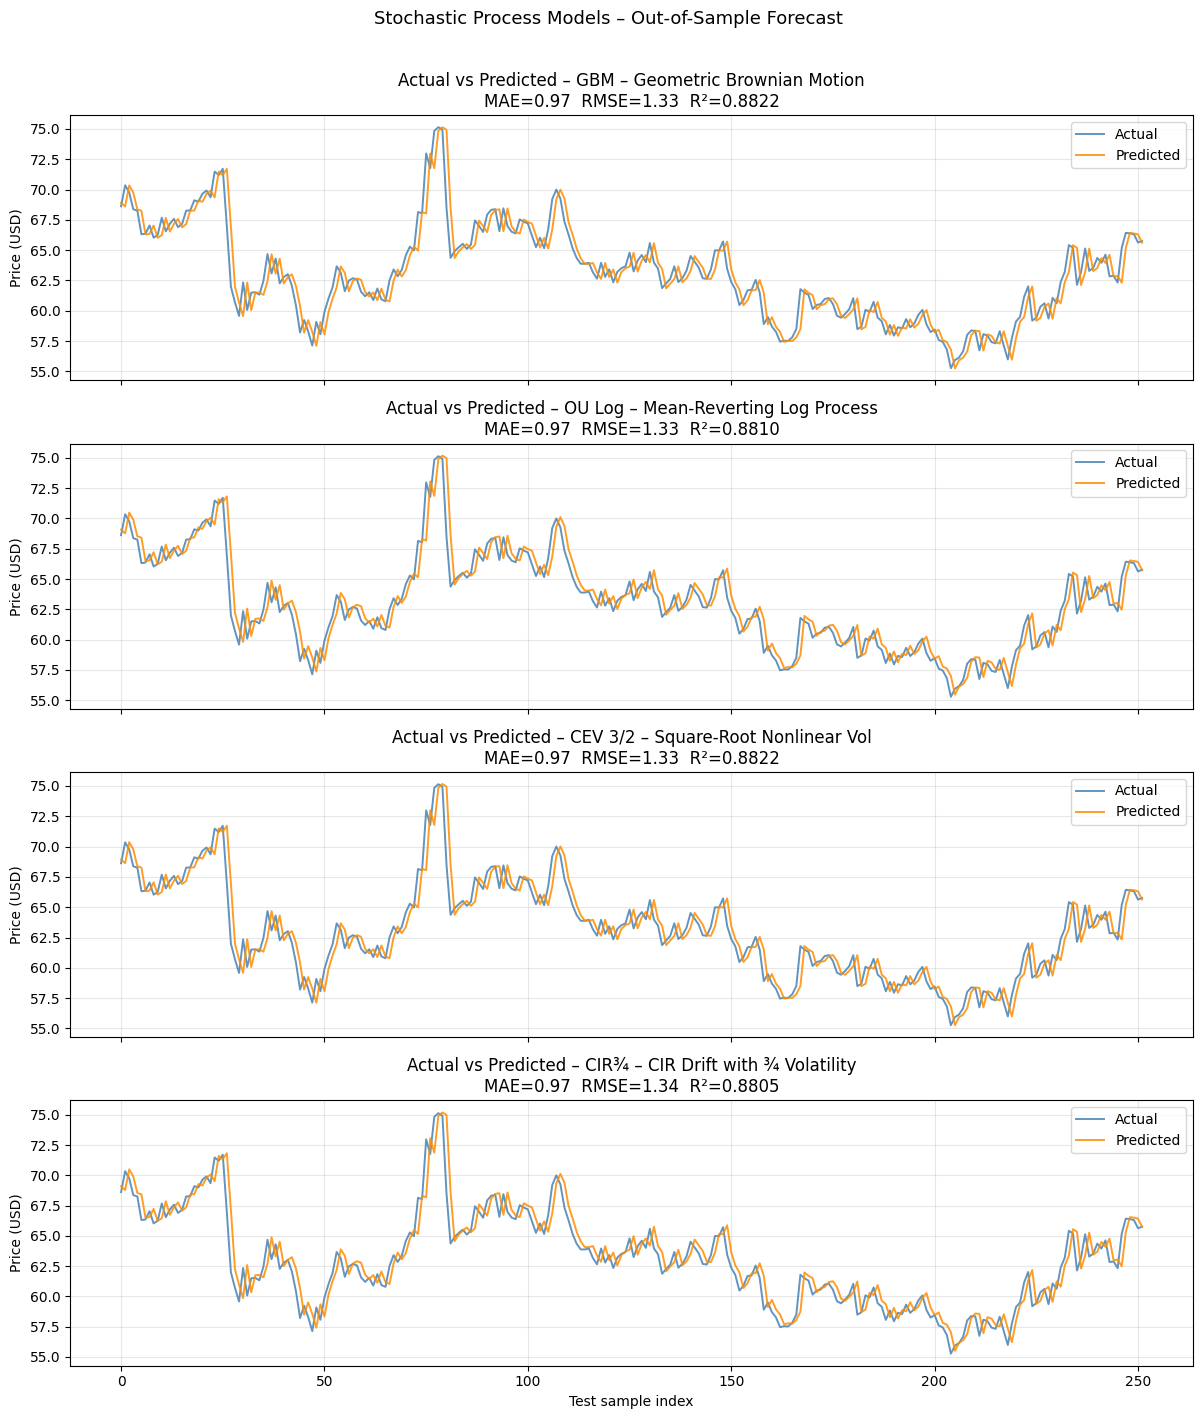

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import yfinance as yf
### ML & preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Configuration -------------------------------------------------------------
OIL_TICKER  = "CL=F"        # WTI Crude Oil futures (Yahoo Finance)
LOOKBACK_DAYS = 30           # Days of lagged features
TEST_SIZE   = 0.2            # 20% for testing (last part of timeline)
RANDOM_STATE = 42
FRED_SERIES  = "DGS10"       # Daily 10-Year US Treasury Constant Maturity Rate
# ---------------------------------------------------------------------------
# Fetch daily 10-year US Treasury rates from FRED.
# start: start date string 'YYYY-MM-DD'
# end:   end date string   'YYYY-MM-DD'
# returns: pandas Series indexed by date (values in % / 100 as decimals)
# ---------------------------------------------------------------------------
def fetch_treasury_rate(start: str, end: str) -> pd.Series:
    """
    Fetch the daily 10-year US Treasury yield from FRED via the public
    FRED CSV API (no API key required).
    Values are returned as decimals (e.g. 0.045 for 4.5 %).
    """
    url = (
        f"https://fred.stlouisfed.org/graph/fredgraph.csv"
        f"?id={FRED_SERIES}&vintage_date={end}"
    )
    print(f"Fetching 10-yr Treasury rates from FRED ({FRED_SERIES})...")
    try:
        rates = pd.read_csv(url, index_col=0, parse_dates=True)
        rates.index.name = "date"
        rates.columns = ["rate"]
        rates = rates.replace(".", np.nan).astype(float)
        rates = rates["rate"] / 100.0          # convert % → decimal
        rates = rates.loc[start:end]
        rates = rates.ffill().dropna()
        print(f"  Retrieved {len(rates)} Treasury rate observations.")
        return rates
    except Exception as e:
        print(f"  WARNING: Could not fetch Treasury rates ({e}). Using fallback r=0.045.")
        idx = pd.date_range(start=start, end=end, freq="B")
        return pd.Series(0.045, index=idx, name="rate")
# ---------------------------------------------------------------------------
# Fetch historical oil price data from Yahoo Finance
# ---------------------------------------------------------------------------
def fetch_oil_data(ticker=OIL_TICKER, years=5):
    end   = datetime.now()
    start = end - timedelta(days=years * 365)
    print(f"Fetching data for {ticker} from {start.date()} to {end.date()}...")
    data  = yf.download(ticker, start=start, end=end, progress=False)
    if data.empty or len(data) < 100:
        raise ValueError("Insufficient data. Check ticker or date range.")
    data = data.dropna(how="all")
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [c[0] if isinstance(c, tuple) else c for c in data.columns]
    data.columns = [str(c).replace(" ", "_").lower() for c in data.columns]
    print(f"Downloaded {len(data)} records.")
    return data
# ---------------------------------------------------------------------------
# Create lagged and rolling features from OHLCV for prediction.
# ---------------------------------------------------------------------------
def create_features(df, lookback=LOOKBACK_DAYS):
    df    = df.copy()
    close = df["close"] if "close" in df.columns else df["adj_close"]
    for lag in [1, 5, 10]:
        df[f"close_lag_{lag}"] = close.shift(lag)
    df["sma_5"]        = close.rolling(5).mean()
    df["sma_20"]       = close.rolling(20).mean()
    df["volatility_10"] = close.rolling(10).std()
    if "high" in df.columns and "low" in df.columns:
        df["range_5"] = (df["high"] - df["low"]).rolling(5).mean()
    df["target"] = close.shift(-1)
    df = df.dropna()
    return df

def get_feature_columns():
    return [
        "close_lag_1", "close_lag_5", "close_lag_10",
        "sma_5", "sma_20", "volatility_10", "range_5"
    ]

def prepare_xy(df, feature_cols):
    X     = df[feature_cols].copy()
    valid = X.notna().all(axis=1)
    X     = X.loc[valid].astype(float)
    y     = df.loc[valid, "target"]
    idx   = df.index[valid]
    return X, y, idx
# ---------------------------------------------------------------------------
# 1) Train Random Forest, SVR, and MLP; return models, scaler, and metrics.
# ---------------------------------------------------------------------------
def train_and_evaluate(X_train, X_test, y_train, y_test, scaler=None):
    if scaler is None:
        scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    models = {
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
        "Support Vector Regression": SVR(kernel="rbf", C=10.0, gamma="scale"),
        "Neural Network": MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=RANDOM_STATE,
            early_stopping=True,
        ),
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train_s, y_train)
        pred = model.predict(X_test_s)
        results[name] = {
            "model":       model,
            "predictions": pred,
            "mae":  mean_absolute_error(y_test, pred),
            "rmse": np.sqrt(mean_squared_error(y_test, pred)),
            "r2":   r2_score(y_test, pred),
        }
        print(f"  {name}: MAE={results[name]['mae']:.2f}, "
              f"RMSE={results[name]['rmse']:.2f}, R²={results[name]['r2']:.4f}")

    return results, scaler
# ---------------------------------------------------------------------------
# 2) STOCHASTIC PROCESS MODELS
#       Estimate GBM parameters (μ, σ) from log-returns of a price series.
#       prices: array-like of closing prices (training window)
#       dt:     time step (1/252 for daily)
#       returns: (mu, sigma) annualised drift and volatility
# ---------------------------------------------------------------------------
def _estimate_gbm_params(prices, dt=1/252):
    log_ret = np.diff(np.log(prices))
    mu      = log_ret.mean() / dt
    sigma   = log_ret.std()  / np.sqrt(dt)
    return mu, sigma
# ---------------------------------------------------------------------------
# Model 1 – Geometric Brownian Motion (GBM)
#   dS = μ S dt + σ S dW
#   One-step-ahead: E[S_{t+1}] = S_t * exp((μ - σ²/2) * dt)
# ---------------------------------------------------------------------------
def gbm_one_step_forecast(prices, dt=1/252):
    mu, sigma = _estimate_gbm_params(prices, dt)
    S0 = prices[-1]
    return S0 * np.exp((mu - 0.5 * sigma**2) * dt)
def gbm_rolling_forecast(prices_train, prices_test, dt=1/252):
    """
    Walk-forward one-step-ahead forecasts using all training data + history
    seen so far in the test window.
    """
    history = list(prices_train)
    preds   = []
    for S_actual in prices_test:
        pred = gbm_one_step_forecast(np.array(history), dt)
        preds.append(pred)
        history.append(S_actual)     # reveal actual and slide window
    return np.array(preds)
# ---------------------------------------------------------------------------
# Model 2 – Mean-Reverting Log Process (Ornstein-Uhlenbeck on log price)
#   d(ln S) = κ (θ – ln S) dt + σ dW
#   Discrete: ln S_{t+1} = ln S_t + κ(θ – ln S_t)*dt + σ*sqrt(dt)*ε
#   E[ln S_{t+1}] = ln S_t + κ(θ – ln S_t)*dt   →  exp(...) for price
# ---------------------------------------------------------------------------
def _estimate_ou_log_params(prices, dt=1/252):
    log_p   = np.log(prices)
    y       = np.diff(log_p)          # Δ(ln S)
    x       = log_p[:-1]              # ln S_t
    # OLS: y = a + b*x  → κ = -b/dt, θ = -a/(b)
    b, a    = np.polyfit(x, y, 1)
    kappa   = max(-b / dt, 1e-6)      # mean-reversion speed (≥0)
    theta   = -a / b if abs(b) > 1e-12 else log_p.mean()
    resid   = y - (a + b * x)
    sigma   = resid.std() / np.sqrt(dt)
    return kappa, theta, sigma
def ou_log_one_step_forecast(prices, dt=1/252):
    kappa, theta, _ = _estimate_ou_log_params(prices, dt)
    log_S0   = np.log(prices[-1])
    log_S1   = log_S0 + kappa * (theta - log_S0) * dt
    return np.exp(log_S1)
def ou_log_rolling_forecast(prices_train, prices_test, dt=1/252):
    history = list(prices_train)
    preds   = []
    for S_actual in prices_test:
        pred = ou_log_one_step_forecast(np.array(history), dt)
        preds.append(pred)
        history.append(S_actual)
    return np.array(preds)
# ---------------------------------------------------------------------------
# Model 3 – Square-Root Process with Nonlinear Volatility (CEV / 3/2 variant)
#   dS = μ S dt + σ S^(3/2) dW
#   One-step-ahead (Euler-Maruyama mean): S_{t+1} ≈ S_t + μ S_t dt
#   (noise term has mean zero; we forecast the conditional mean)
# ---------------------------------------------------------------------------
def _estimate_sqrtnonlin_params(prices, dt=1/252):
    log_ret = np.diff(np.log(prices))
    mu      = log_ret.mean() / dt
    # σ estimated from scaled residuals: ε_t = (ΔS_t - μ S_t dt) / (S_t^1.5 * sqrt(dt))
    S       = prices[:-1]
    dS      = np.diff(prices)
    resid   = dS - mu * S * dt
    vol_adj = S ** 1.5 * np.sqrt(dt)
    sigma   = np.std(resid / vol_adj)
    return mu, sigma
def sqrtnonlin_one_step_forecast(prices, dt=1/252):
    mu, _ = _estimate_sqrtnonlin_params(prices, dt)
    S0    = prices[-1]
    return S0 * np.exp(mu * dt)          # conditional mean in log-space
def sqrtnonlin_rolling_forecast(prices_train, prices_test, dt=1/252):
    history = list(prices_train)
    preds   = []
    for S_actual in prices_test:
        pred = sqrtnonlin_one_step_forecast(np.array(history), dt)
        preds.append(pred)
        history.append(S_actual)
    return np.array(preds)
# ---------------------------------------------------------------------------
# Model 4 – CIR Drift with ¾ Volatility (3/4-power CEV)
#   dS = κ(θ – S) dt + σ S^(3/4) dW
#   Conditional mean (Euler): E[S_{t+1}] = S_t + κ(θ – S_t)*dt
#   Requires risk-free rate r (for risk-neutral drift adjustment if desired).
# ---------------------------------------------------------------------------
def _estimate_cir34_params(prices, dt=1/252):
    S   = prices[:-1]
    dS  = np.diff(prices)
    # OLS: dS = a + b*S  → κ = -b/dt, θ = -a/b
    b, a = np.polyfit(S, dS, 1)
    kappa = max(-b / dt, 1e-6)
    theta = -a / b if abs(b) > 1e-12 else prices.mean()
    resid = dS - (a + b * S)
    vol_adj = S ** 0.75 * np.sqrt(dt)
    sigma = np.std(resid / np.clip(vol_adj, 1e-8, None))
    return kappa, theta, sigma
def cir34_one_step_forecast(prices, r=0.045, dt=1/252):
    """
    r: current annualised risk-free rate (10-yr Treasury yield).
    The risk-free rate enters as an additive risk-neutral adjustment.
    """
    kappa, theta, _ = _estimate_cir34_params(prices, dt)
    S0   = prices[-1]
    # Risk-neutral mean-reversion target shifted by r
    theta_rn = theta + r / kappa if kappa > 0 else theta
    return S0 + kappa * (theta_rn - S0) * dt
def cir34_rolling_forecast(prices_train, prices_test, rate_series, dt=1/252):
    """
    rate_series: array of daily risk-free rates aligned with prices_test.
    """
    history = list(prices_train)
    preds   = []
    for i, S_actual in enumerate(prices_test):
        r    = float(rate_series[i]) if i < len(rate_series) else 0.045
        pred = cir34_one_step_forecast(np.array(history), r=r, dt=dt)
        preds.append(pred)
        history.append(S_actual)
    return np.array(preds)
# ---------------------------------------------------------------------------
# Compute and print metrics for stochastic models.
# ---------------------------------------------------------------------------
def evaluate_stochastic(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
    return {"predictions": y_pred, "mae": mae, "rmse": rmse, "r2": r2}
# ---------------------------------------------------------------------------
# Print next-day forecasts for all four stochastic models.
# ---------------------------------------------------------------------------
def print_stochastic_next_day(close_prices, treasury_rate):
    print("\n--- Stochastic Models: Next Trading Day Forecast ---")
    p = close_prices.values

    gbm_pred  = gbm_one_step_forecast(p)
    ou_pred   = ou_log_one_step_forecast(p)
    sq_pred   = sqrtnonlin_one_step_forecast(p)
    cir_pred  = cir34_one_step_forecast(p, r=treasury_rate)

    print(f"  GBM  (Geometric Brownian Motion)       : ${gbm_pred:.2f} USD")
    print(f"  OU   (Mean-Reverting Log Process)       : ${ou_pred:.2f} USD")
    print(f"  CEV  (Square-Root Nonlinear Vol, 3/2)   : ${sq_pred:.2f} USD")
    print(f"  CIR¾ (CIR Drift, ¾ Vol)                 : ${cir_pred:.2f} USD")
# ---------------------------------------------------------------------------
# Plot actual vs predicted for stochastic models.
# ---------------------------------------------------------------------------
def plot_stochastic_models(y_test, stochastic_results, dates_test):
    n_models  = len(stochastic_results)
    fig, axes = plt.subplots(n_models, 1,
                             figsize=(12, 3.5 * n_models), sharex=True)
    if n_models == 1:
        axes = [axes]
    x_idx = range(len(dates_test))

    for ax, (name, res) in zip(axes, stochastic_results.items()):
        ax.plot(x_idx, y_test.values, label="Actual",    color="steelblue",  alpha=0.85, linewidth=1.4)
        ax.plot(x_idx, res["predictions"], label="Predicted", color="darkorange", alpha=0.85, linewidth=1.4)
        ax.set_ylabel("Price (USD)")
        ax.set_title(
            f"Actual vs Predicted – {name}\n"
            f"MAE={res['mae']:.2f}  RMSE={res['rmse']:.2f}  R²={res['r2']:.4f}"
        )
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Test sample index")
    plt.suptitle("Stochastic Process Models – Out-of-Sample Forecast", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
# ---------------------------------------------------------------------------
# Plot actual vs predicted for ML models (unchanged from original).
# ---------------------------------------------------------------------------
def plot_actual_vs_predicted(y_test, predictions_dict, dates_test):
    n_models  = len(predictions_dict)
    fig, axes = plt.subplots(n_models, 1,
                             figsize=(10, 3 * n_models), sharex=True)
    if n_models == 1:
        axes = [axes]
    dates_plot = range(len(dates_test))

    for ax, (name, pred) in zip(axes, predictions_dict.items()):
        ax.plot(dates_plot, y_test.values, label="Actual",    color="steelblue", alpha=0.8)
        ax.plot(dates_plot, pred,          label="Predicted", color="coral",     alpha=0.8)
        ax.set_ylabel("Price (USD)")
        ax.set_title(f"Actual vs Predicted – {name}")
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Test sample index")
    plt.tight_layout()
    plt.show()
# ---------------------------------------------------------------------------
# ML next-day prediction (original function, unchanged).
# ---------------------------------------------------------------------------
def print_next_day_prediction(df, feature_cols, results, scaler):
    last = df[feature_cols].iloc[-1:]
    if last.isna().any().any():
        print("Skipping ML next-day prediction (missing values in last row).")
        return
    X_last = scaler.transform(last)
    print("\n--- ML Models: Next Trading Day Forecast ---")
    for model_name in ["Random Forest", "Support Vector Regression", "Neural Network"]:
        pred = results[model_name]["model"].predict(X_last)[0]
        print(f"  {model_name}: ${pred:.2f} USD")
# ===========================================================================
#  MAIN
# ===========================================================================
def main():
    print(" === Oil Price Prediction App (ML + Stochastic) === ")

    # 1. Load oil price data
    df = fetch_oil_data(OIL_TICKER, years=5)

    # 2. Fetch 10-yr Treasury rates (needed for CIR¾ model)
    start_date = str(df.index[0].date())
    end_date   = str(df.index[-1].date())
    treasury   = fetch_treasury_rate(start_date, end_date)

    # Align treasury rates to trading days in df
    treasury_aligned = treasury.reindex(df.index, method="ffill").fillna(0.045)

    # -----------------------------------------------------------------------
    # ML SECTION
    # -----------------------------------------------------------------------
    feature_cols = get_feature_columns()
    df_feat      = create_features(df, lookback=LOOKBACK_DAYS)

    available = [c for c in feature_cols
                 if c in df_feat.columns and df_feat[c].notna().all()]
    if len(available) < len(feature_cols):
        feature_cols = available

    X, y, idx = prepare_xy(df_feat, feature_cols)

    n         = len(X)
    split_idx = int(n * (1 - TEST_SIZE))
    X_train, X_test = X.iloc[:split_idx],  X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx],  y.iloc[split_idx:]
    dates_test      = idx[split_idx:]

    print(f"\nTrain samples: {len(X_train)}, Test samples: {len(X_test)}")
    print(f"Features: {feature_cols}")

    print("\nML Model performance (test set):")
    ml_results, scaler = train_and_evaluate(X_train, X_test, y_train, y_test)

    best_ml = max(ml_results, key=lambda k: ml_results[k]["r2"])
    print(f"Best ML model by R²: {best_ml} (R²={ml_results[best_ml]['r2']:.4f})")

    print_next_day_prediction(df_feat, feature_cols, ml_results, scaler)

    plot_actual_vs_predicted(
        y_test,
        {k: v["predictions"] for k, v in ml_results.items()},
        dates_test,
    )

    # -----------------------------------------------------------------------
    # STOCHASTIC SECTION
    # -----------------------------------------------------------------------
    close = df["close"] if "close" in df.columns else df["adj_close"]
    close = close.dropna()

    # Align treasury to close index, then split identically to ML split
    treas_aligned = treasury.reindex(close.index, method="ffill").fillna(0.045)

    # Use same proportional split on the *full* close series
    n_close       = len(close)
    split_c       = int(n_close * (1 - TEST_SIZE))
    close_train   = close.iloc[:split_c]
    close_test    = close.iloc[split_c:]         # "actual" next-day prices
    treas_test    = treas_aligned.iloc[split_c:].values

    # The "true" targets for the test window are already close_test
    # (one-step-ahead = next actual close vs. previous prediction)
    # We compare predicted[i] with actual close[split_c + i]
    y_stoch_actual = close_test   # pandas Series; forecasts predict these values

    print("\nStochastic Model performance (test set, one-step-ahead walk-forward):")
    gbm_preds  = gbm_rolling_forecast(close_train.values,  close_test.values)
    ou_preds   = ou_log_rolling_forecast(close_train.values, close_test.values)
    sq_preds   = sqrtnonlin_rolling_forecast(close_train.values, close_test.values)
    cir_preds  = cir34_rolling_forecast(close_train.values, close_test.values, treas_test)

    stochastic_results = {
        "GBM – Geometric Brownian Motion":          evaluate_stochastic("GBM",  y_stoch_actual, gbm_preds),
        "OU Log – Mean-Reverting Log Process":       evaluate_stochastic("OU",   y_stoch_actual, ou_preds),
        "CEV 3/2 – Square-Root Nonlinear Vol":       evaluate_stochastic("CEV",  y_stoch_actual, sq_preds),
        "CIR¾ – CIR Drift with ¾ Volatility":        evaluate_stochastic("CIR¾", y_stoch_actual, cir_preds),
    }

    best_stoch = max(stochastic_results, key=lambda k: stochastic_results[k]["r2"])
    print(f"Best Stochastic model by R²: {best_stoch} "
          f"(R²={stochastic_results[best_stoch]['r2']:.4f})")

    # Next-day forecast (stochastic models)
    latest_rate = float(treas_aligned.iloc[-1])
    print_stochastic_next_day(close, latest_rate)

    # Actual vs predicted plot for stochastic models
    plot_stochastic_models(y_stoch_actual, stochastic_results, close_test.index)
if __name__ == "__main__":
    main()